In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
from pathlib import Path 
from tqdm import tqdm 
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
adata = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_filtered_.h5ad")
adata[adata.obs.experiment_number==210].obs.loc[:, ['740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]',
       'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]',
       'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]',
       'il3_[ng_ml]', 'source_id', 'days_of_culture', 'o2_[%]']]

,740-yp_[µm],mtg_[µm],rhflt3l_[ng_ml],gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],source_id,days_of_culture,o2_[%]
124883-707,5,100,10,0,0.0,0,70,0.0,0,100,0,0,0.0,cb3,14,20
257601-707,5,100,10,0,0.0,0,70,0.0,0,100,0,0,0.0,cb3,14,20
302964-705,5,100,10,0,0.0,0,70,0.0,0,100,0,0,0.0,cb3,14,20
158408-705,5,100,10,0,0.0,0,70,0.0,0,100,0,0,0.0,cb3,14,20
234210-705,5,100,10,0,0.0,0,70,0.0,0,100,0,0,0.0,cb3,14,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31587-707,5,100,10,0,0.0,0,70,0.0,0,100,0,0,0.0,cb3,14,20
38281-705,5,100,10,0,0.0,0,70,0.0,0,100,0,0,0.0,cb3,14,20
68487-705,5,100,10,0,0.0,0,70,0.0,0,100,0,0,0.0,cb3,14,20
74821-707,5,100,10,0,0.0,0,70,0.0,0,100,0,0,0.0,cb3,14,20


/tmp/ipykernel_1916720/1450165540.py:1: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(figsize=(6,5))


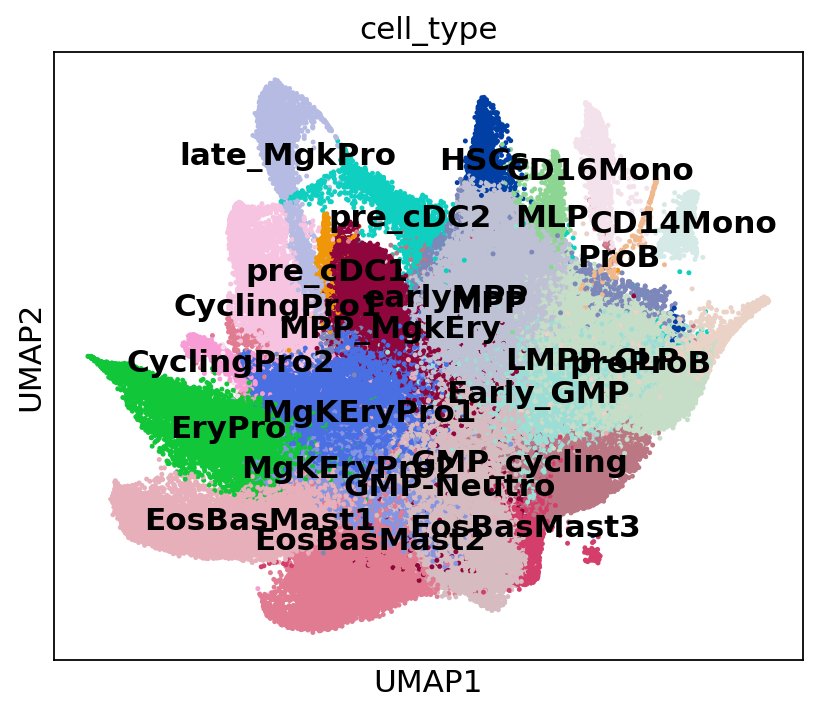

In [3]:
sc.settings.set_figure_params(figsize=(6,5))
sc.pl.umap(
    adata,
    color="cell_type",
    s=20,
    legend_loc="on data"
)

In [4]:
adata.obs.cell_type.value_counts()/adata.obs.shape[0]

cell_type
MPP            0.174531
GMP-Neutro     0.155933
MgKEryPro1     0.131599
LMPP-CLP       0.085534
Early_GMP      0.077234
EosBasMast2    0.067791
GMP_cycling    0.061197
MPP_MgkEry     0.052840
EosBasMast1    0.048104
MgKEryPro2     0.044357
EryPro         0.035940
CyclingPro1    0.021321
late_MgkPro    0.009474
HSCs           0.005655
earlyMPP       0.004849
pre_cDC2       0.004826
EosBasMast3    0.004162
MLP            0.003452
preProB        0.003376
CD16Mono       0.002571
CyclingPro2    0.001980
pre_cDC1       0.001492
CD14Mono       0.001414
ProB           0.000369
Name: count, dtype: float64

In [5]:
to_keep = ["CD14Mono",
            "CD16Mono",
            "CyclingPro1",
            "CyclingPro2",
            "EosBasMast1",
            "EosBasMast2",
            "EosBasMast3",
            "EryPro",
            "HSCs",
            "ProB",
            "late_MgkPro",
            'GMP-Neutro',
            'preProB',
            'pre_cDC1']

In [6]:
adata.obs.cell_type.value_counts().loc[to_keep].sort_values(ascending=False)

cell_type
GMP-Neutro     73575
EosBasMast2    31986
EosBasMast1    22697
EryPro         16958
CyclingPro1    10060
late_MgkPro     4470
HSCs            2668
EosBasMast3     1964
preProB         1593
CD16Mono        1213
CyclingPro2      934
pre_cDC1         704
CD14Mono         667
ProB             174
Name: count, dtype: int64

## Check cell type profiles per unique protocol 

In [7]:
adata.obs.columns

Index(['experiment_number', 'replicate', 'date', 'cytometer',
       'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts',
       'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]',
       'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]',
       'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]',
       'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]',
       'source_cell_phenotype', 'total_count_beads',
       'counts_source_cell_phenotype', 'days_of_culture', 'plate',
       'absolute_number_multiplier_[2^n]', 'cytometer_id',
       'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width',
       'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width',
       'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub',
       'leiden_old', 'cell_type'],
      dtype='object')

In [8]:
protocol_columns = ["740-yp_[µm]", 
                   "mtg_[µm]", 
                   "rhflt3l_[ng_ml]", 
                   "gm-csf_[ng_ml]", 
                   "tpo_[ng_ml]",
                   "sr1_[nm]", 
                   "um171_[nm]", 
                   "um729_[µm]", 
                   "scf_[ng_ml]",
                   "butyzamide_[nm]",
                   "retinoic_acid_[µm]",
                   "ldl_[ng_ml]", 
                   "il3_[ng_ml]", 
                   "o2_[%]", 
                   "days_of_culture"]

In [9]:
for p in protocol_columns:
    print(p)
    print(np.array(adata.obs[p].unique()))
    print()

740-yp_[µm]
[5]

mtg_[µm]
[100]

rhflt3l_[ng_ml]
[10]

gm-csf_[ng_ml]
['10' '0' '1']

tpo_[ng_ml]
[2.5  0.   0.5  1.   0.25]

sr1_[nm]
[375 750   0  75]

um171_[nm]
[1120    0  560   70  280]

um729_[µm]
[0.   1.5  0.75]

scf_[ng_ml]
[50  0 10]

butyzamide_[nm]
[  0 100]

retinoic_acid_[µm]
[0 1 5]

ldl_[ng_ml]
[ 0  2 10 50 20  5]

il3_[ng_ml]
[ 0.  10.   5.  20.   2.5]

o2_[%]
[20 10]

days_of_culture
[21 13 14 27 28 36 15]



In [10]:
# Obs 
cell_type_proportions = {cell_type: [] for cell_type in adata.obs.cell_type.unique()}
cell_counts = []
experiment_id = []

# X 
obs_protocols = adata.obs.loc[:, protocol_columns].values.astype(float)
X = np.unique(obs_protocols, axis=0)

In [11]:
for unique_protocol in tqdm(X):
    idx = (adata.obs.loc[:, protocol_columns].values.astype(float)==unique_protocol[None, :]).all(1)
    adata_protocol = adata[idx]
    proportions = adata_protocol.obs.cell_type.value_counts()/adata_protocol.shape[0]
    for cell_type in cell_type_proportions: 
        if cell_type in proportions.index.values:
            cell_type_proportions[cell_type].append(proportions[cell_type])
        else:
            cell_type_proportions[cell_type].append(0.0)
    
    cell_counts.append(adata_protocol.shape[0])
    experiment_id.append(np.unique(adata_protocol.obs.experiment_number))

100%|██████████| 103/103 [00:38<00:00,  2.64it/s]


In [12]:
proportion_df = pd.DataFrame(cell_type_proportions)
proportion_df["cell_counts"] = cell_counts
# proportion_df["experiment_id"] = experiment_id

protocol_adata = sc.AnnData(X=np.log1p(X), obs=proportion_df)
protocol_adata.var.index = protocol_columns

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [13]:
argmax_protocols = np.argmax(protocol_adata.obs, axis=0)

In [14]:
adata_argmax = protocol_adata[argmax_protocols]
adata_argmax.obs["cell_type"] = np.array(adata_argmax.obs.columns)

/tmp/ipykernel_1916720/824891330.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_argmax.obs["cell_type"] = np.array(adata_argmax.obs.columns)
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


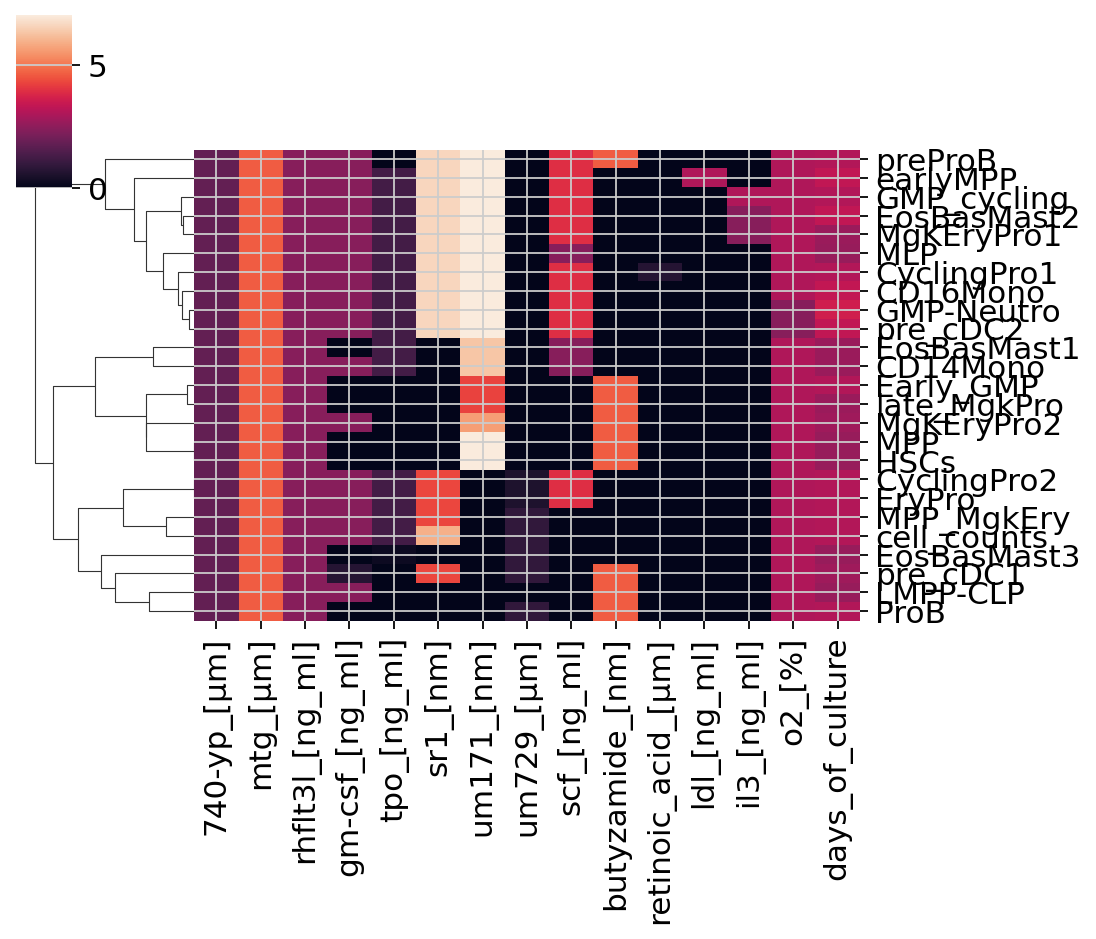

In [15]:
sns.clustermap(
    adata_argmax.X,
    yticklabels=adata_argmax.obs["cell_type"], 
    xticklabels=adata_argmax.var.index, 
    figsize=(7, 6),
    col_cluster=False
)
plt.show()

In [16]:
protocol_adata

AnnData object with n_obs × n_vars = 103 × 15
    obs: 'LMPP-CLP', 'GMP_cycling', 'EosBasMast2', 'MgKEryPro1', 'GMP-Neutro', 'EosBasMast3', 'Early_GMP', 'MPP', 'MgKEryPro2', 'EosBasMast1', 'pre_cDC2', 'preProB', 'MPP_MgkEry', 'pre_cDC1', 'MLP', 'earlyMPP', 'CyclingPro1', 'CyclingPro2', 'CD14Mono', 'HSCs', 'EryPro', 'late_MgkPro', 'CD16Mono', 'ProB', 'cell_counts'

In [17]:
# for cell_type in protocol_adata.obs.columns:

#     to_plot_df = pd.DataFrame(protocol_adata.X)
#     to_plot_df.columns = protocol_adata.var.index
#     to_plot_df[f"{cell_type} proportions"] = np.array(protocol_adata.obs[cell_type])

#     protocols = protocol_adata.var.index

#     n_cols = 4
#     n_rows = int(np.ceil(len(protocols) / n_cols))

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10))
#     axes = axes.flatten()

#     for i, protocol in enumerate(protocols):
#         sns.regplot(
#             data=to_plot_df,
#             x=protocol,
#             y=f"{cell_type} proportions",
#             ax=axes[i],
#             scatter_kws={"s": 10},
#             line_kws={"color": "red"}
#         )
#         axes[i].set_title(protocol)

#     for j in range(len(protocols), len(axes)):
#         fig.delaxes(axes[j])

#     fig.suptitle(f"{cell_type}", fontsize=16)
#     plt.tight_layout()
#     plt.show()

In [18]:
adata_argmax.obs.drop(["cell_type"], axis=1).max(0)

LMPP-CLP           0.297328
GMP_cycling        0.218654
EosBasMast2        0.408742
MgKEryPro1         0.351799
GMP-Neutro         0.665340
EosBasMast3        0.037866
Early_GMP          0.324344
MPP                0.761563
MgKEryPro2         0.450625
EosBasMast1        0.334009
pre_cDC2           0.064441
preProB            0.010091
MPP_MgkEry         0.466726
pre_cDC1           0.012088
MLP                0.025214
earlyMPP           0.018999
CyclingPro1        0.704545
CyclingPro2        0.032233
CD14Mono           0.007501
HSCs               0.068761
EryPro             0.316938
late_MgkPro        0.715066
CD16Mono           0.043888
ProB               0.002957
cell_counts    11645.000000
dtype: float64

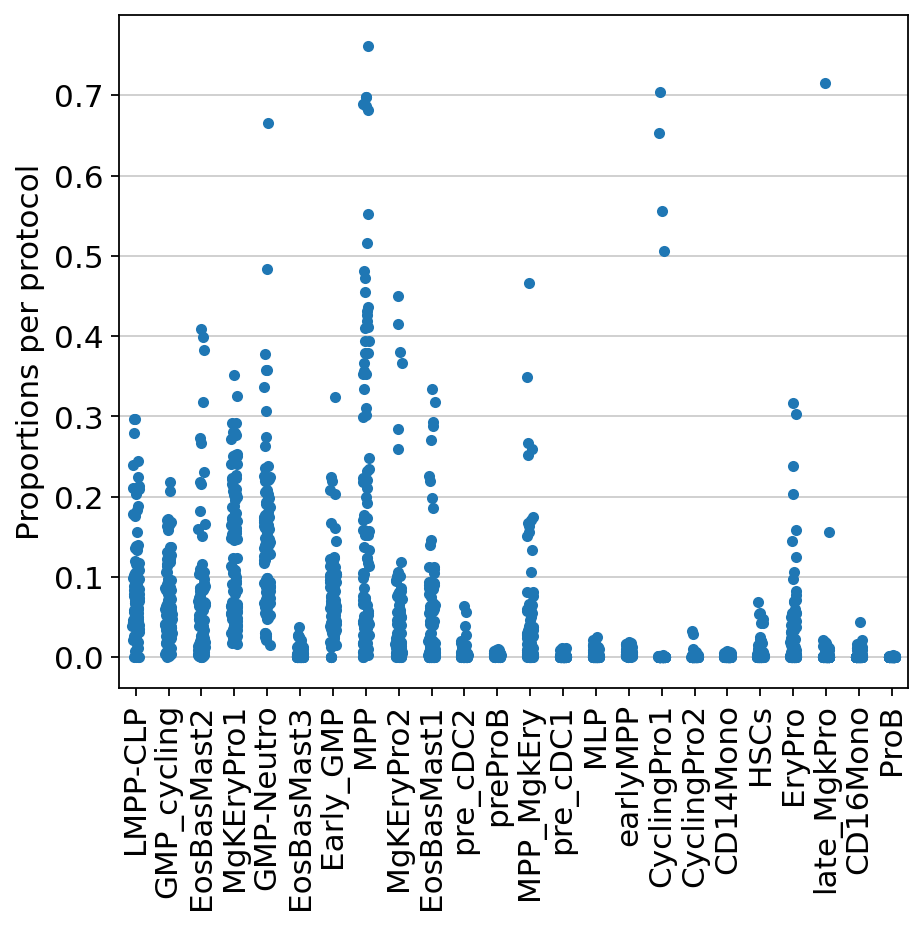

In [19]:
df = protocol_adata.obs.melt()

plt.figure(figsize=(6, 6))

sns.stripplot(
    data=df[df.variable!="cell_counts"],
    x="variable",
    y="value",
    # showfliers=False  # cleaner look (optional)
)

plt.xticks(rotation=90)  # rotate labels
plt.xlabel("")
plt.ylabel("Proportions per protocol")
# plt.title("Proportions per protocols (103 unique protocols)", fontsize=14)

plt.tight_layout()
plt.show()

In [20]:
protocol_adata.obs["experiment_id"] = experiment_id

In [21]:
protocol_adata[protocol_adata.obs["late_MgkPro"]>0.15].obs

,LMPP-CLP,GMP_cycling,EosBasMast2,MgKEryPro1,GMP-Neutro,EosBasMast3,Early_GMP,MPP,MgKEryPro2,EosBasMast1,...,CyclingPro1,CyclingPro2,CD14Mono,HSCs,EryPro,late_MgkPro,CD16Mono,ProB,cell_counts,experiment_id
3,0.026309,0.001489,0.001986,0.023827,0.030032,0.000000,0.026557,0.037726,0.040953,0.067511,...,0.000000,0.000000,0.001241,0.001737,0.022834,0.715066,0.0,0.000000,4029,[210]
4,0.077190,0.000742,0.016329,0.048491,0.121722,0.000742,0.324344,0.113558,0.058634,0.016081,...,0.000495,0.000247,0.000247,0.000000,0.060614,0.155863,0.0,0.000495,4042,[1089]


In [22]:
adata.obs.experiment_number = adata.obs.experiment_number.astype("category")

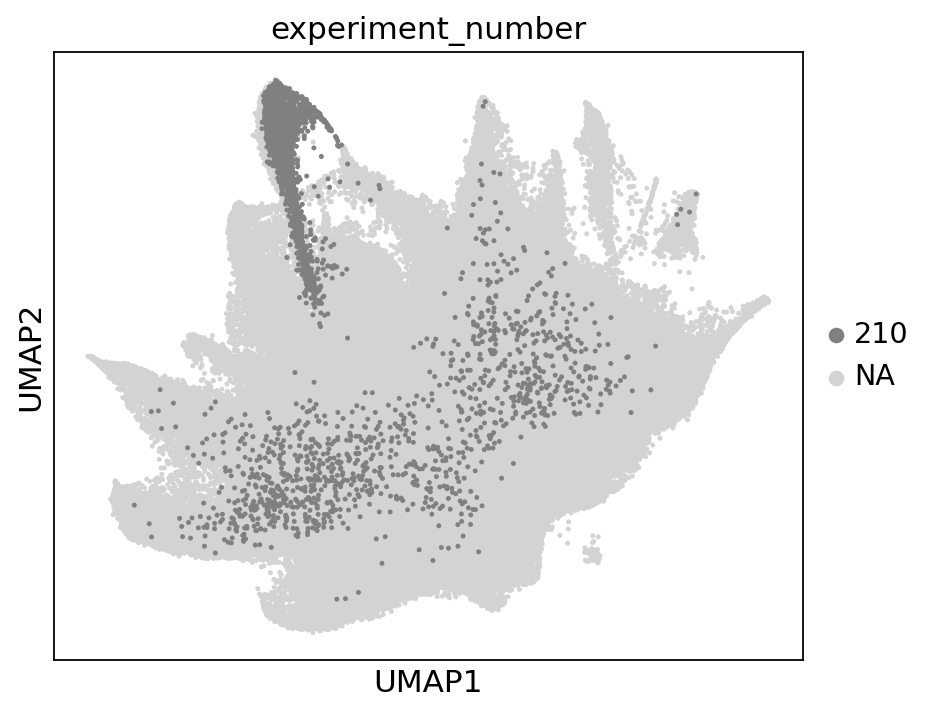

In [23]:
sc.pl.umap(adata, s=20, color="experiment_number", groups=[210])

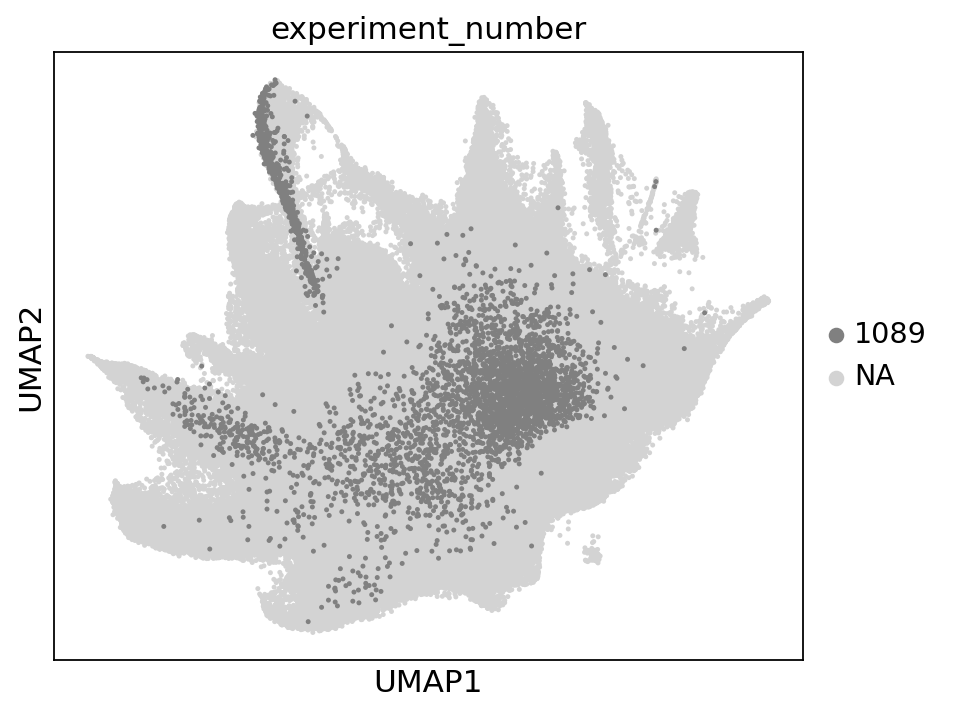

In [24]:
sc.pl.umap(adata, s=20, color="experiment_number", groups=[1089])

## Save the results

In [26]:
# protocol_adata.write_h5ad("protocol_adata.h5ad")

## Check cell type overlaps 

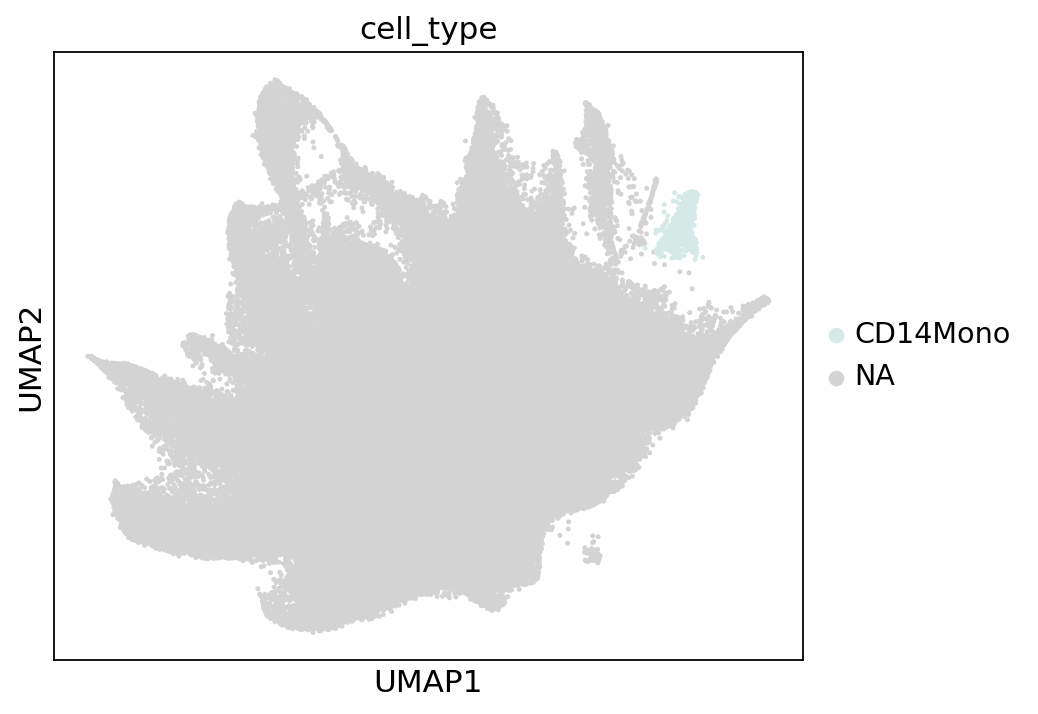

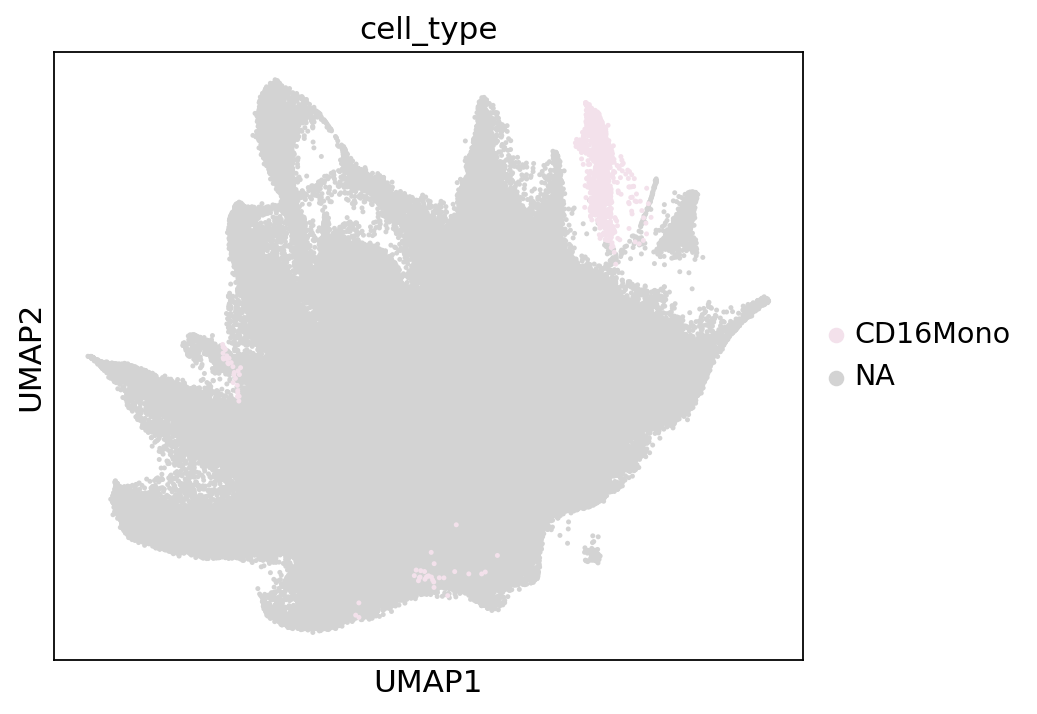

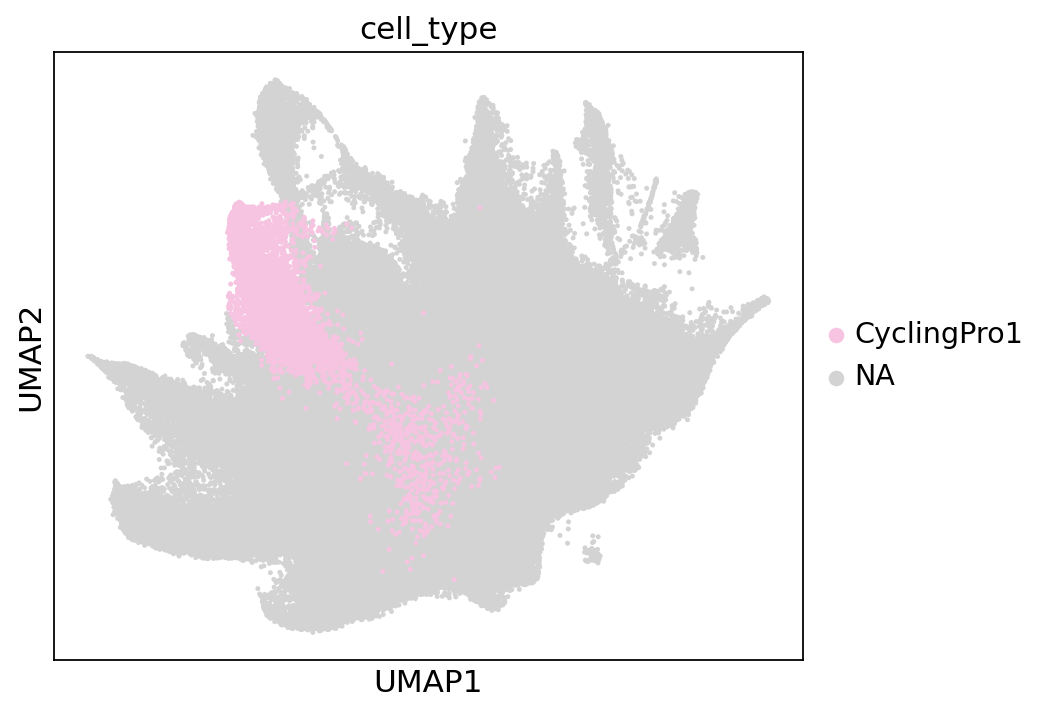

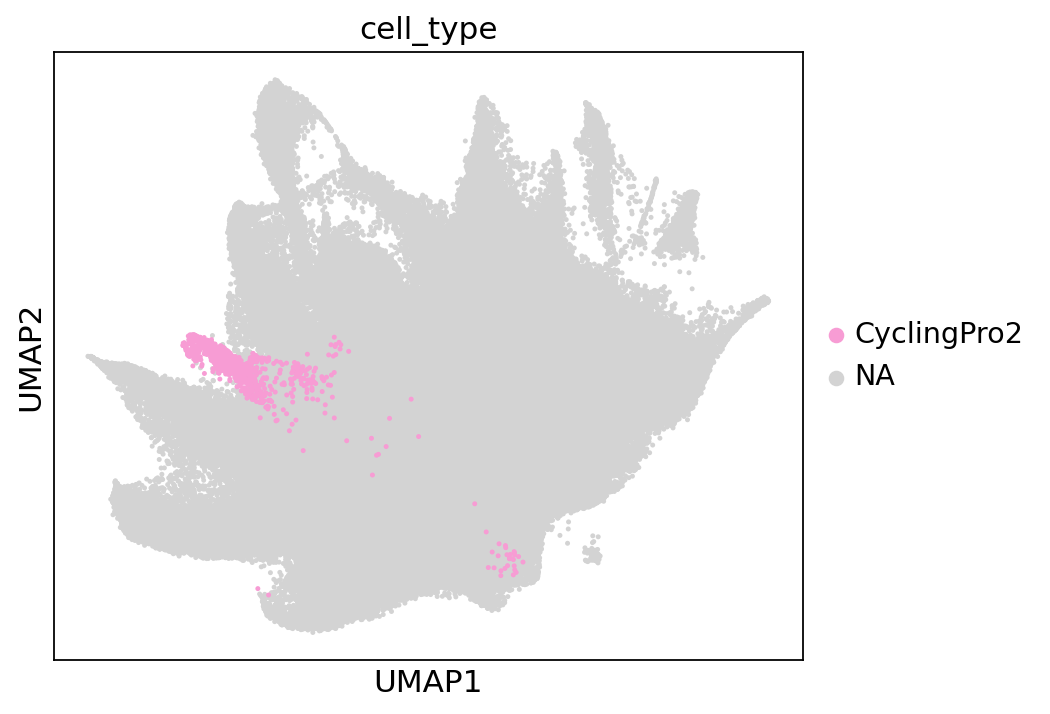

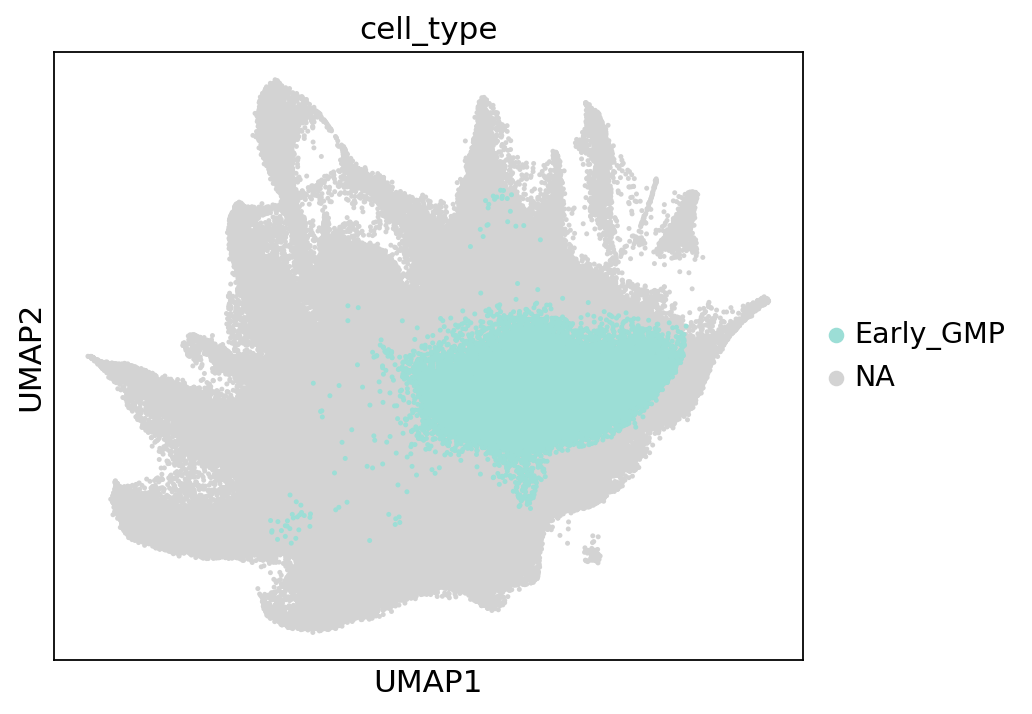

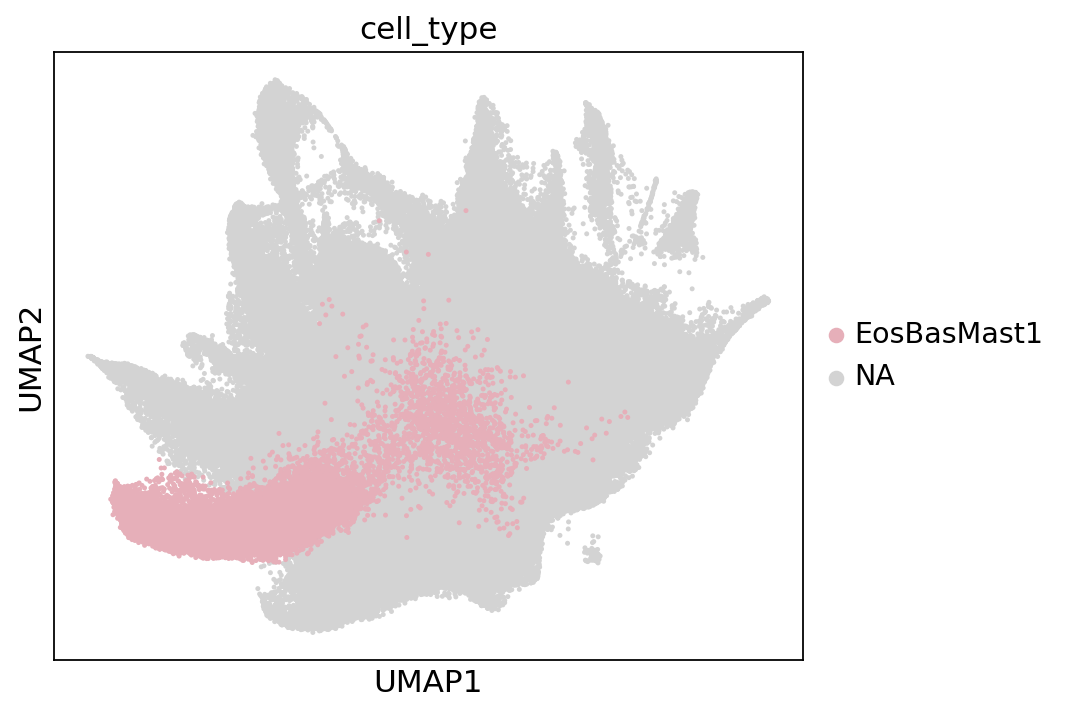

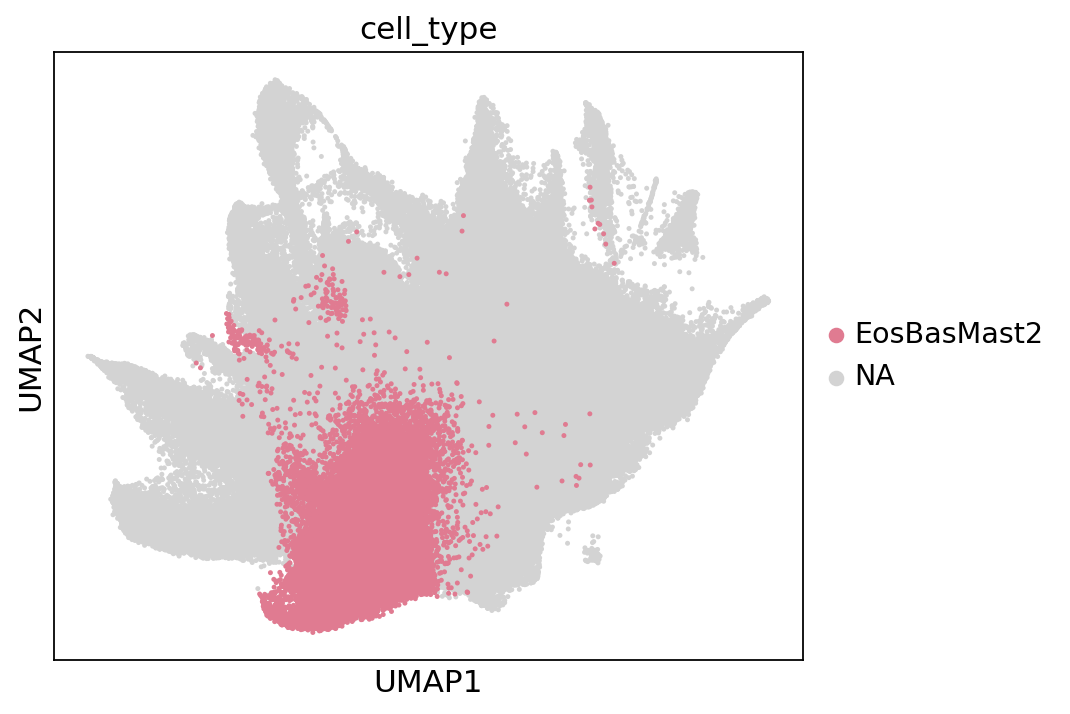

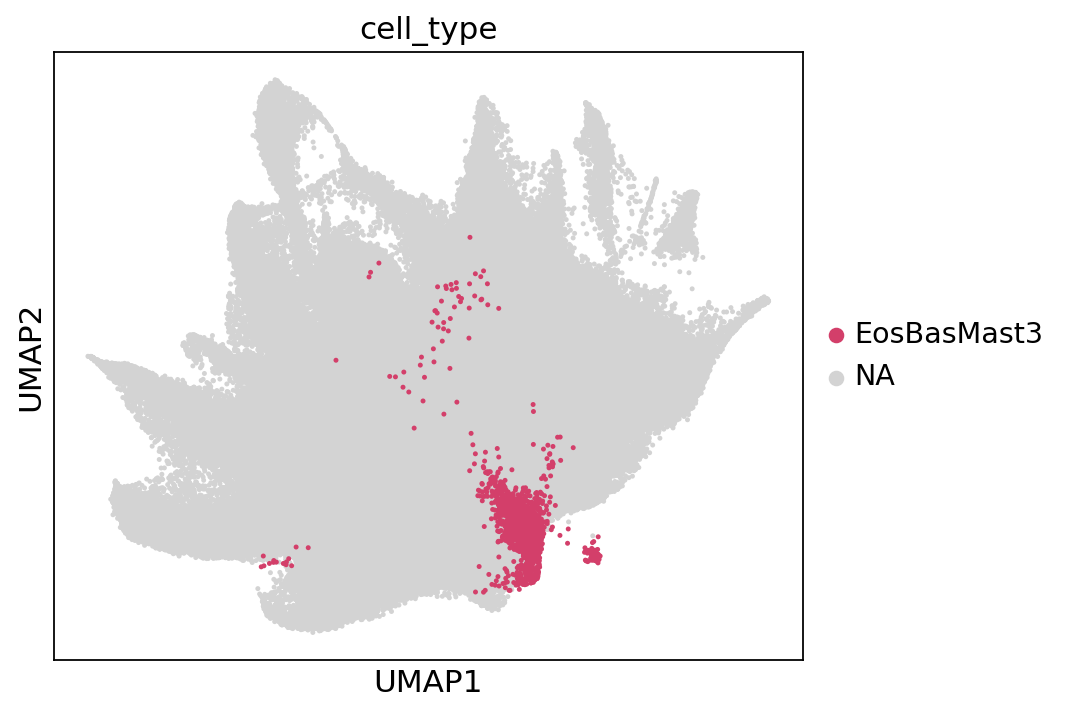

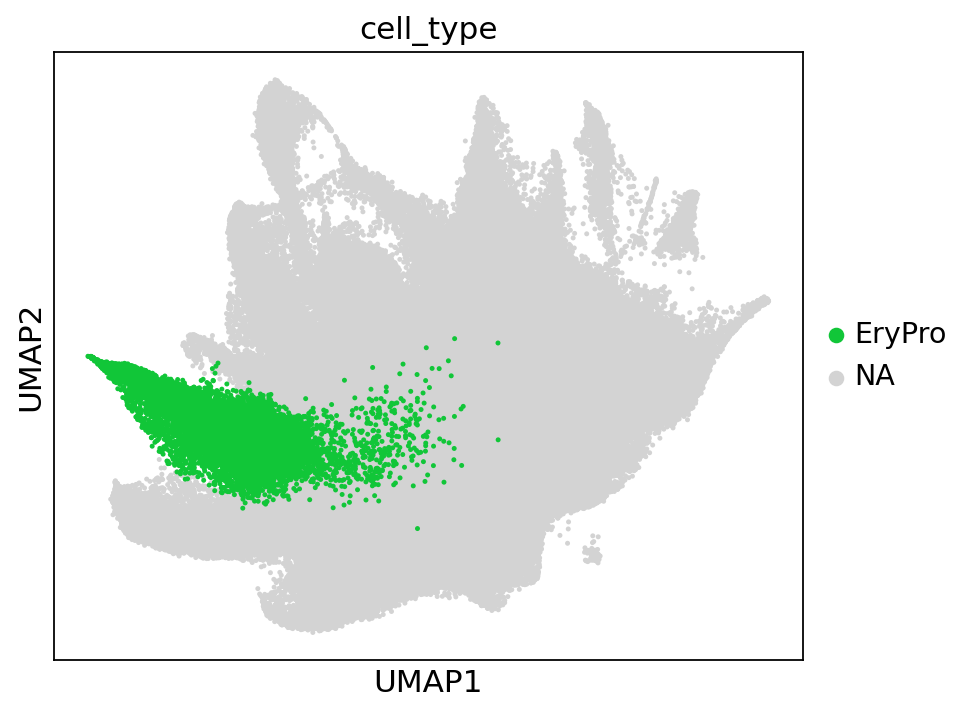

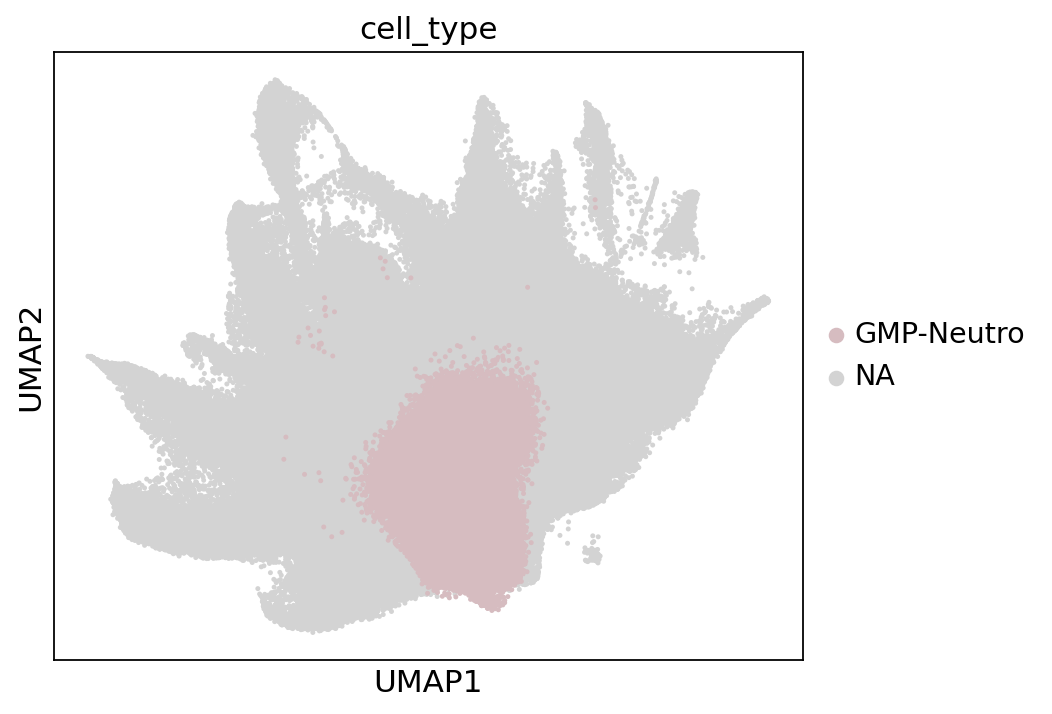

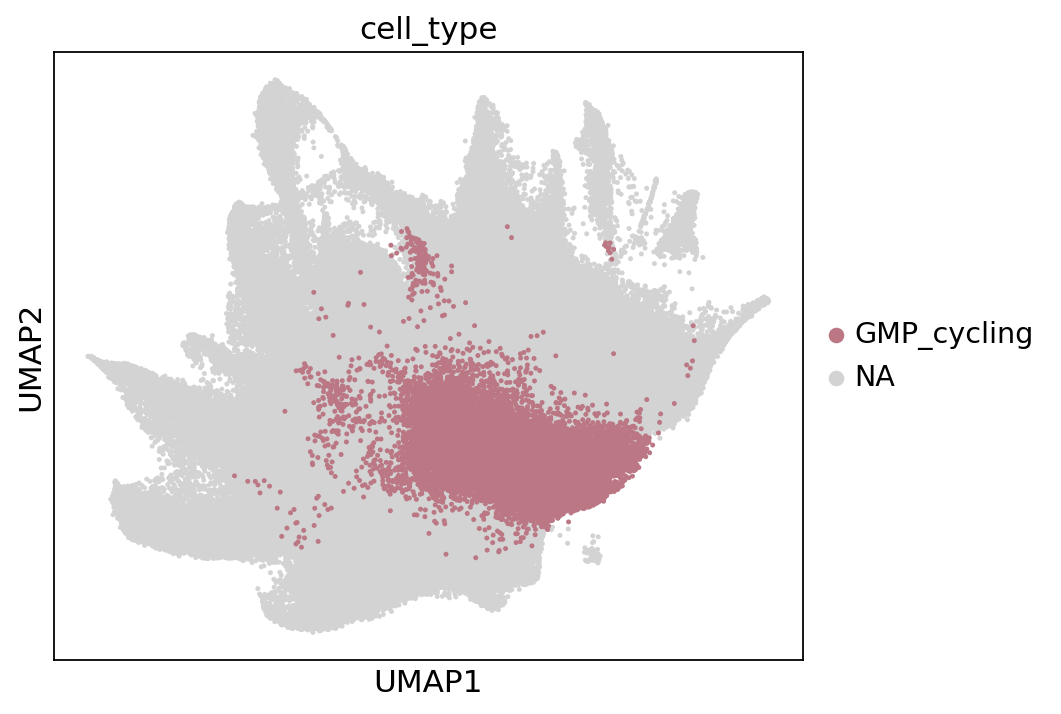

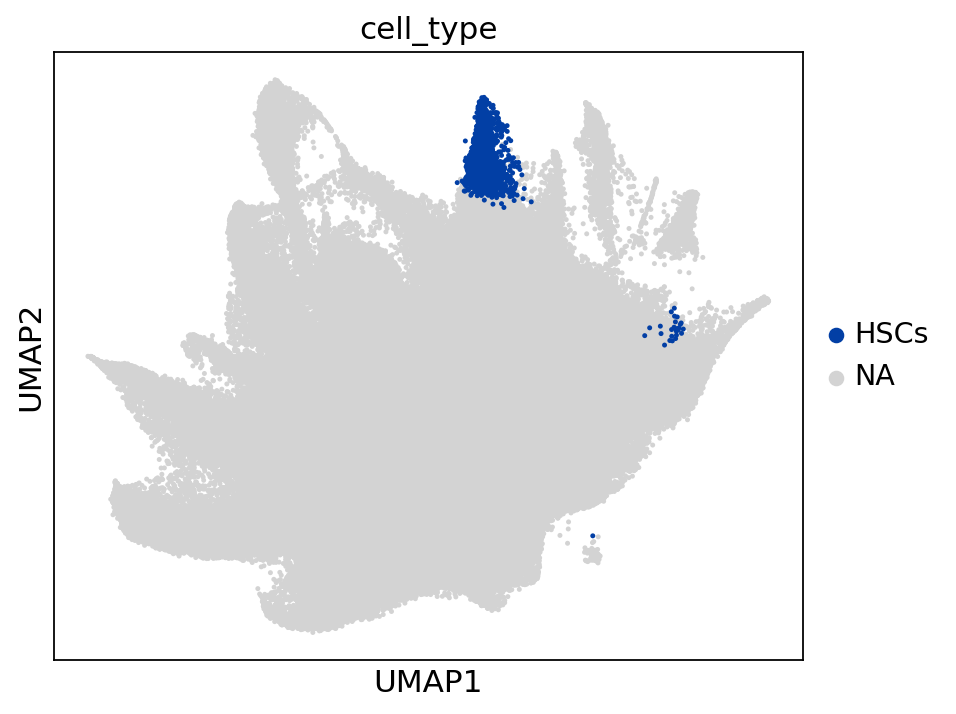

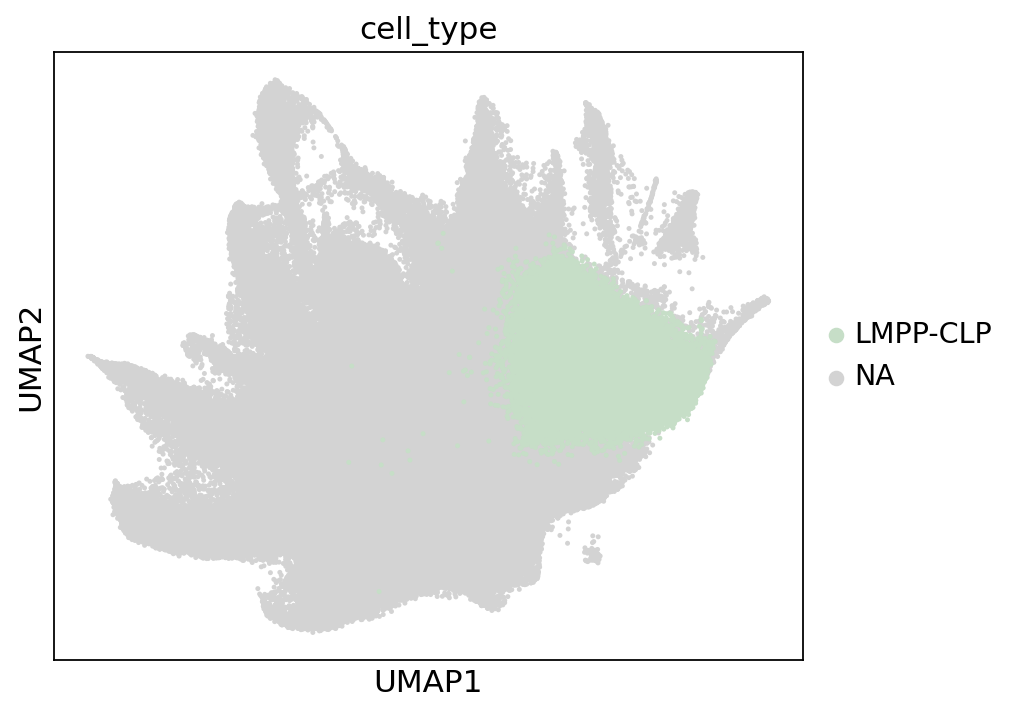

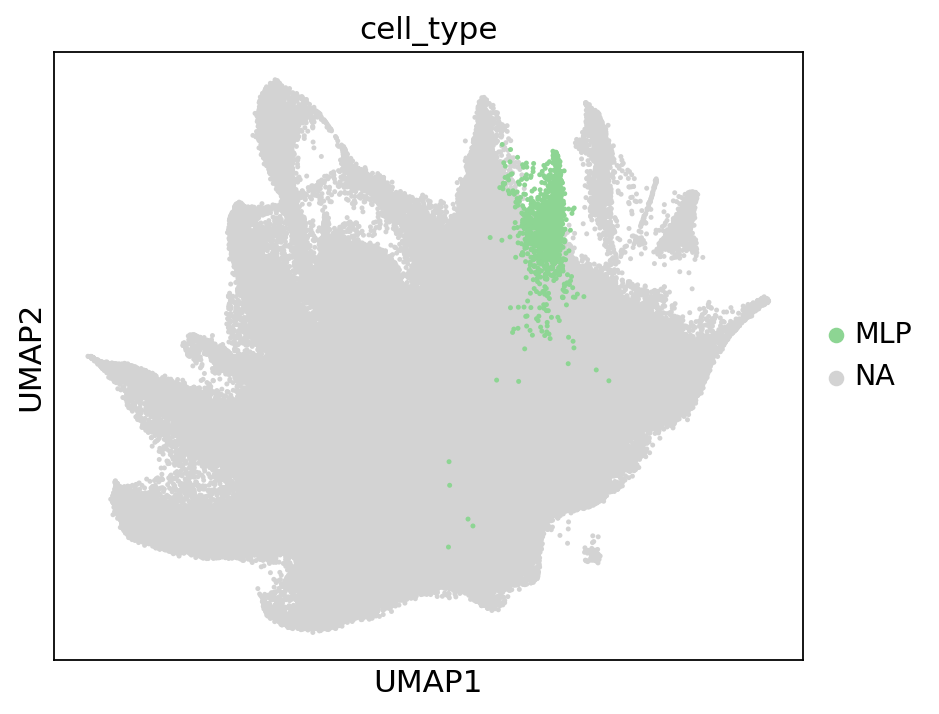

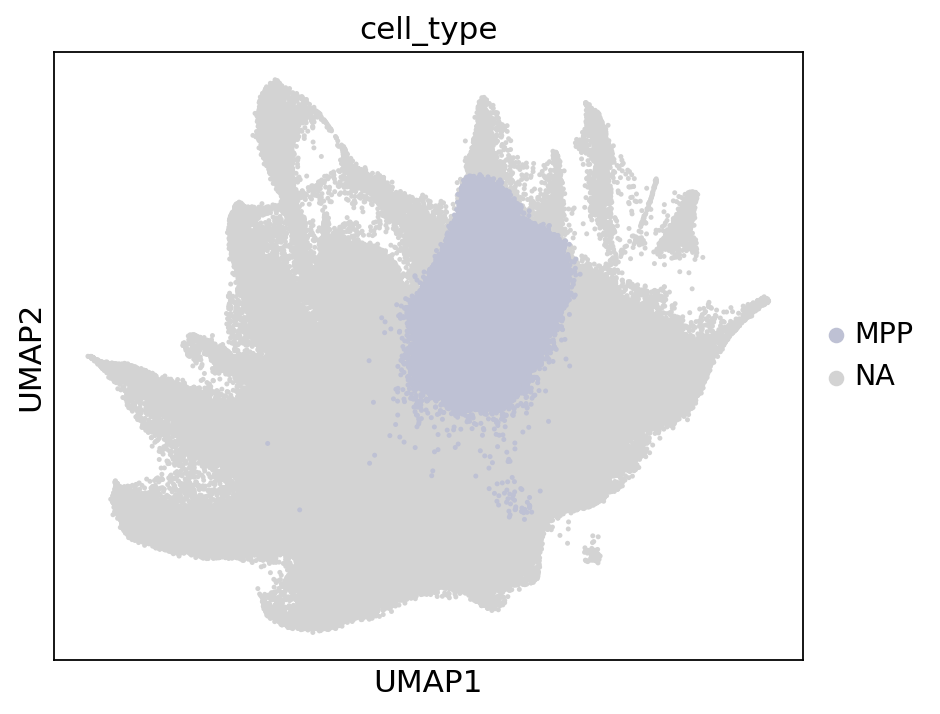

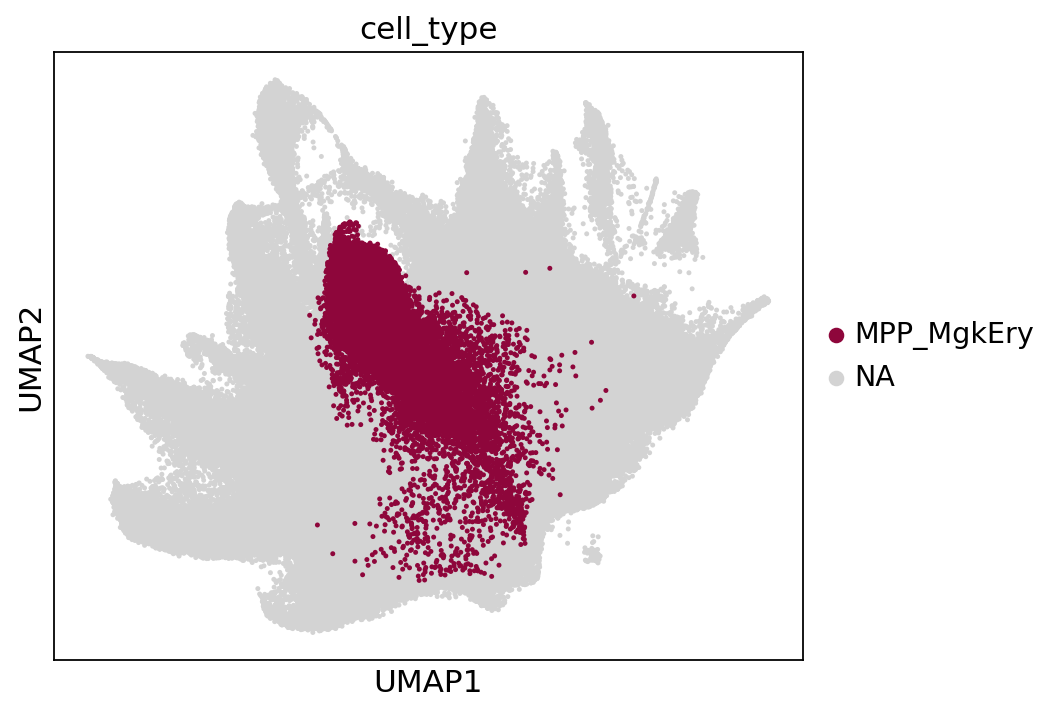

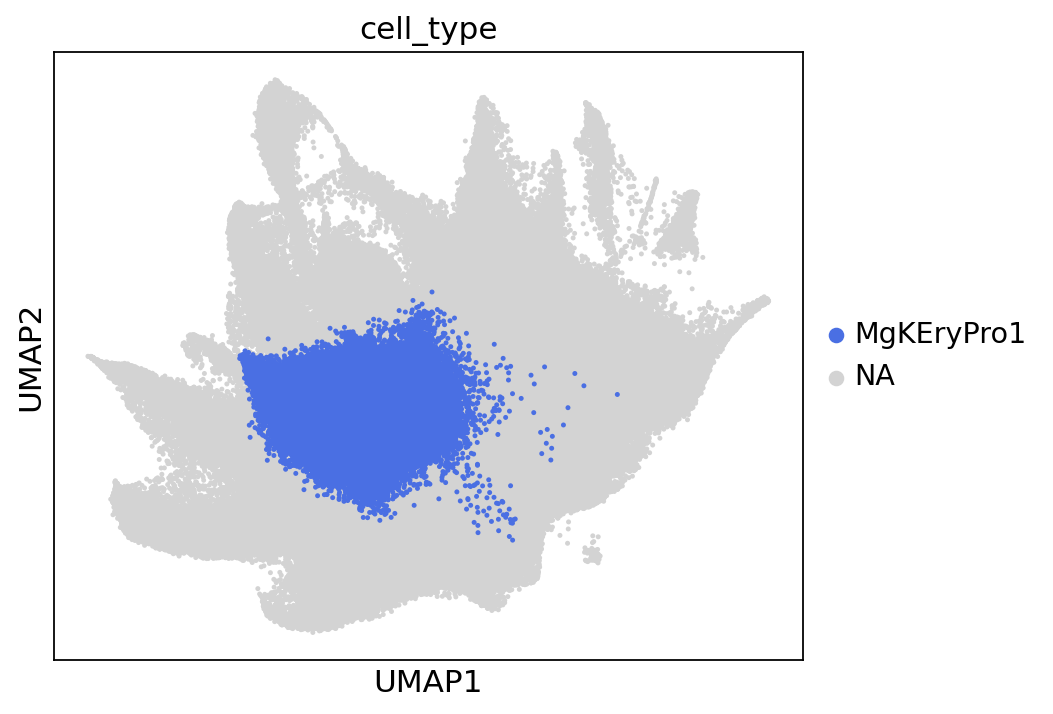

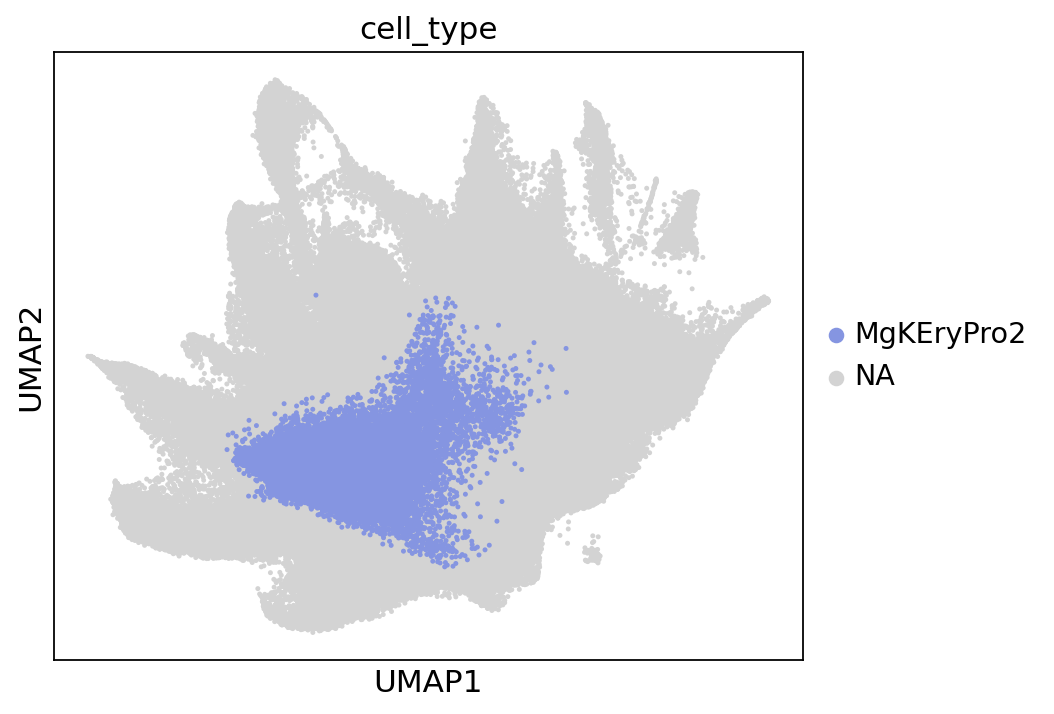

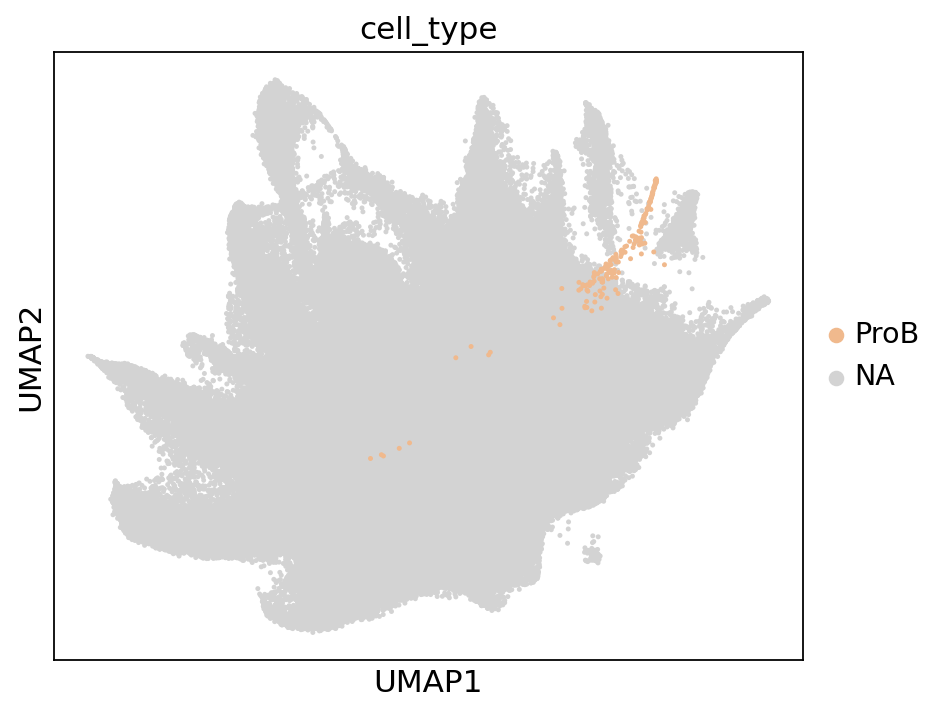

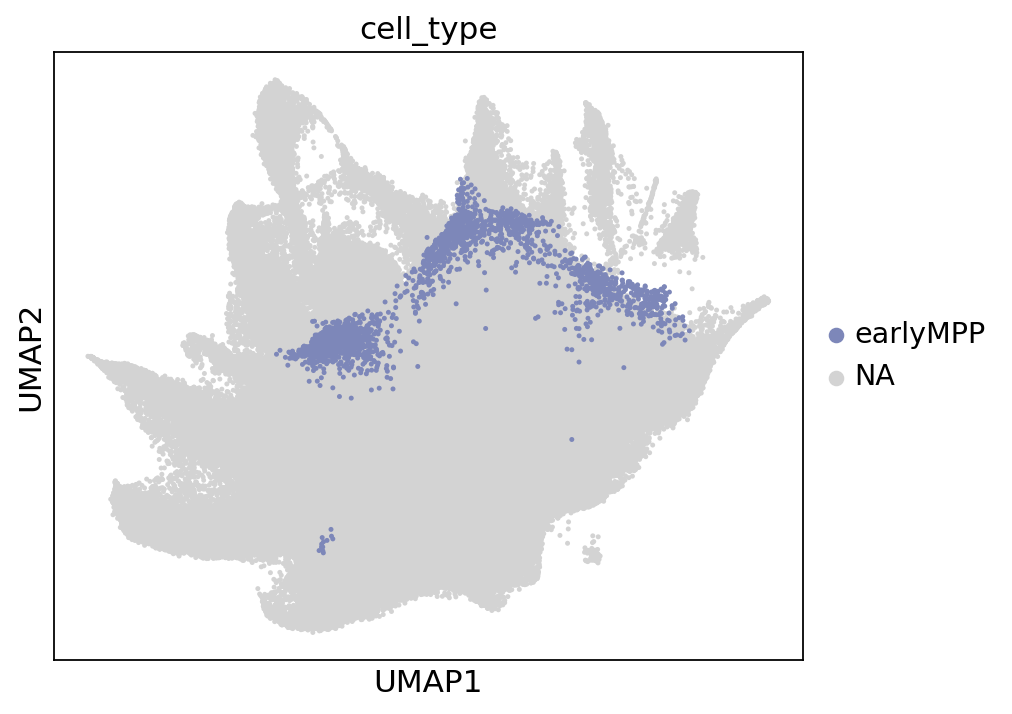

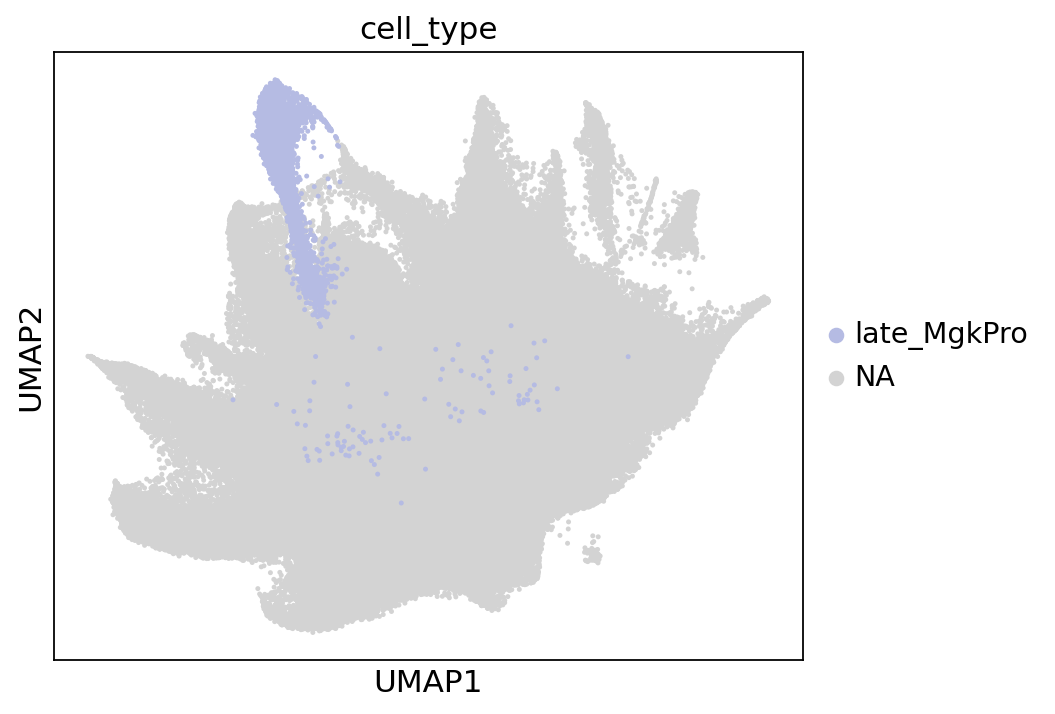

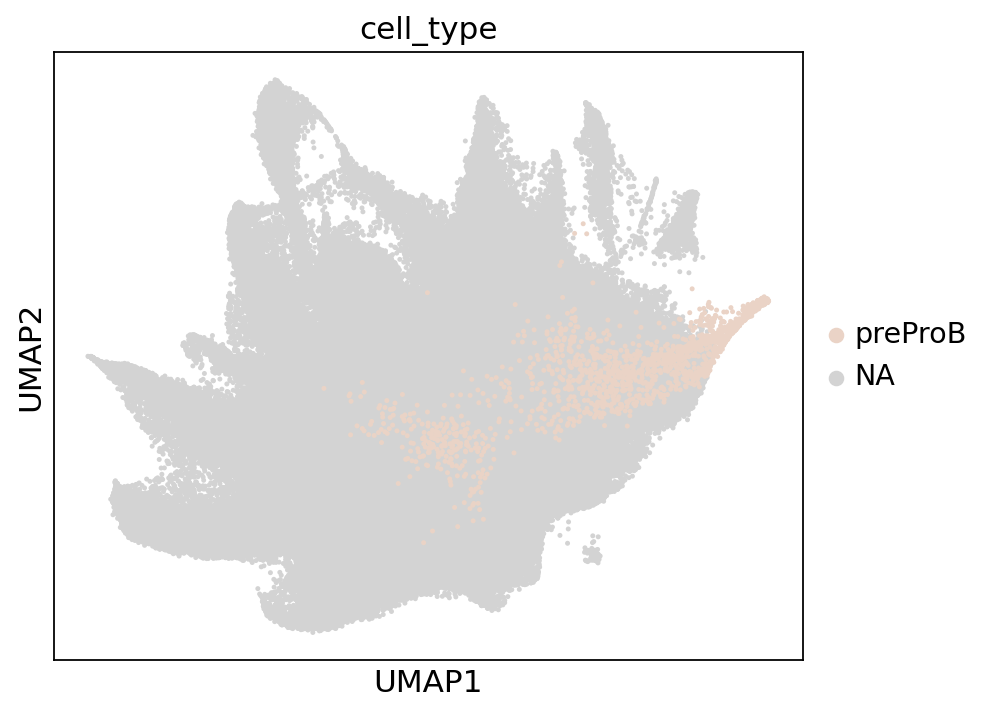

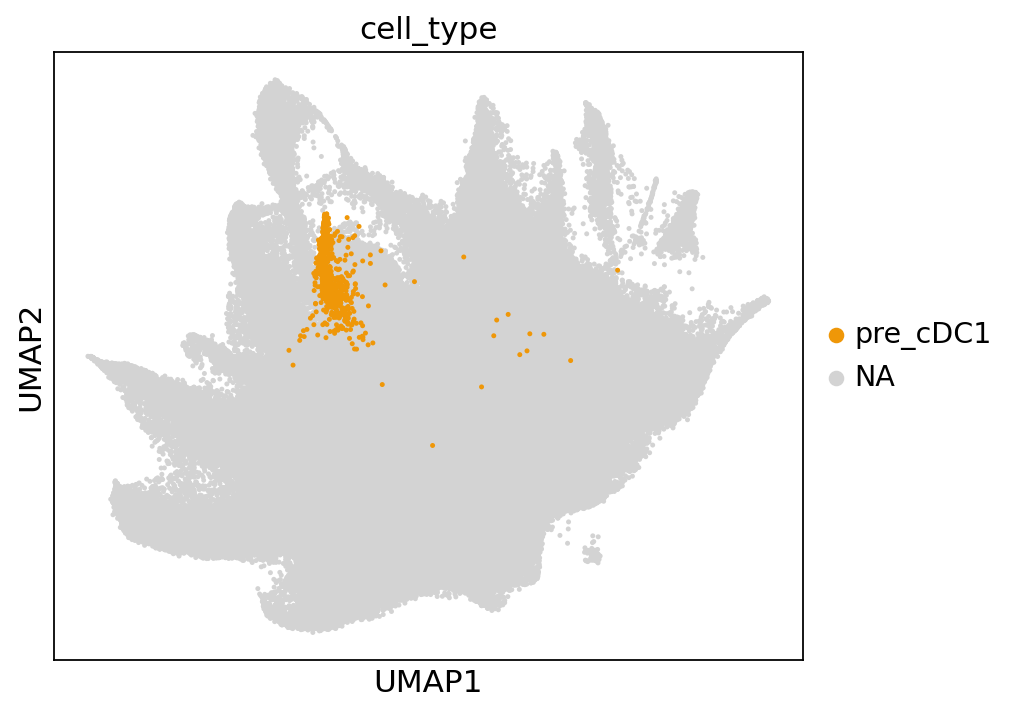

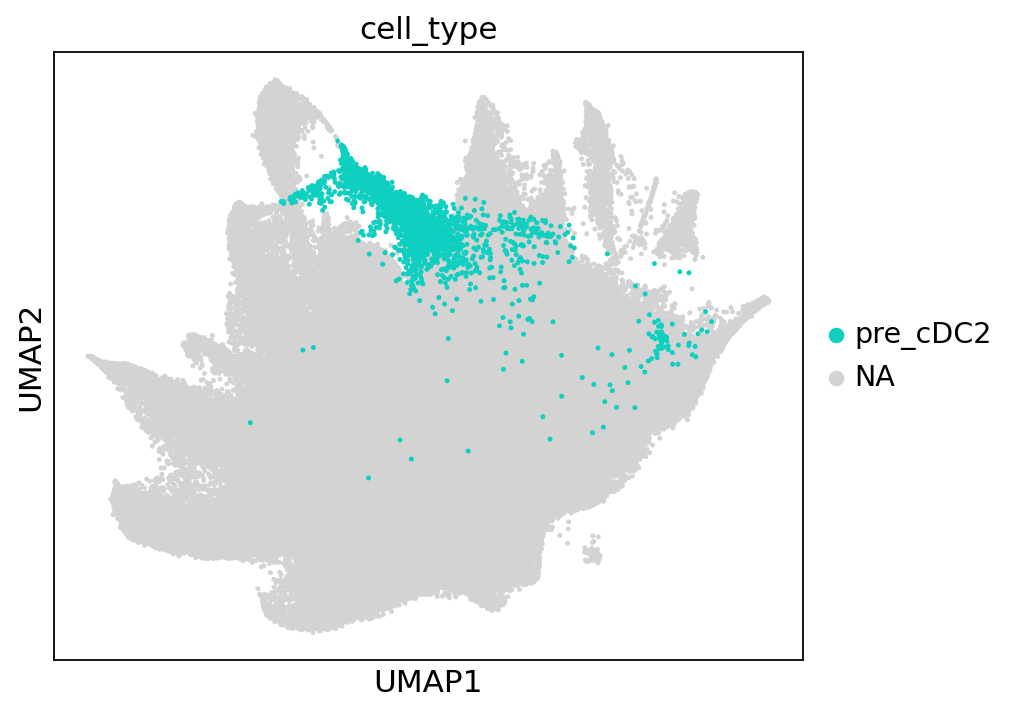

In [27]:
for cell_type in np.unique(adata.obs.cell_type):
    sc.pl.umap(
    adata,
        color="cell_type",
        s=20,
        groups=[cell_type]
    )

## Features

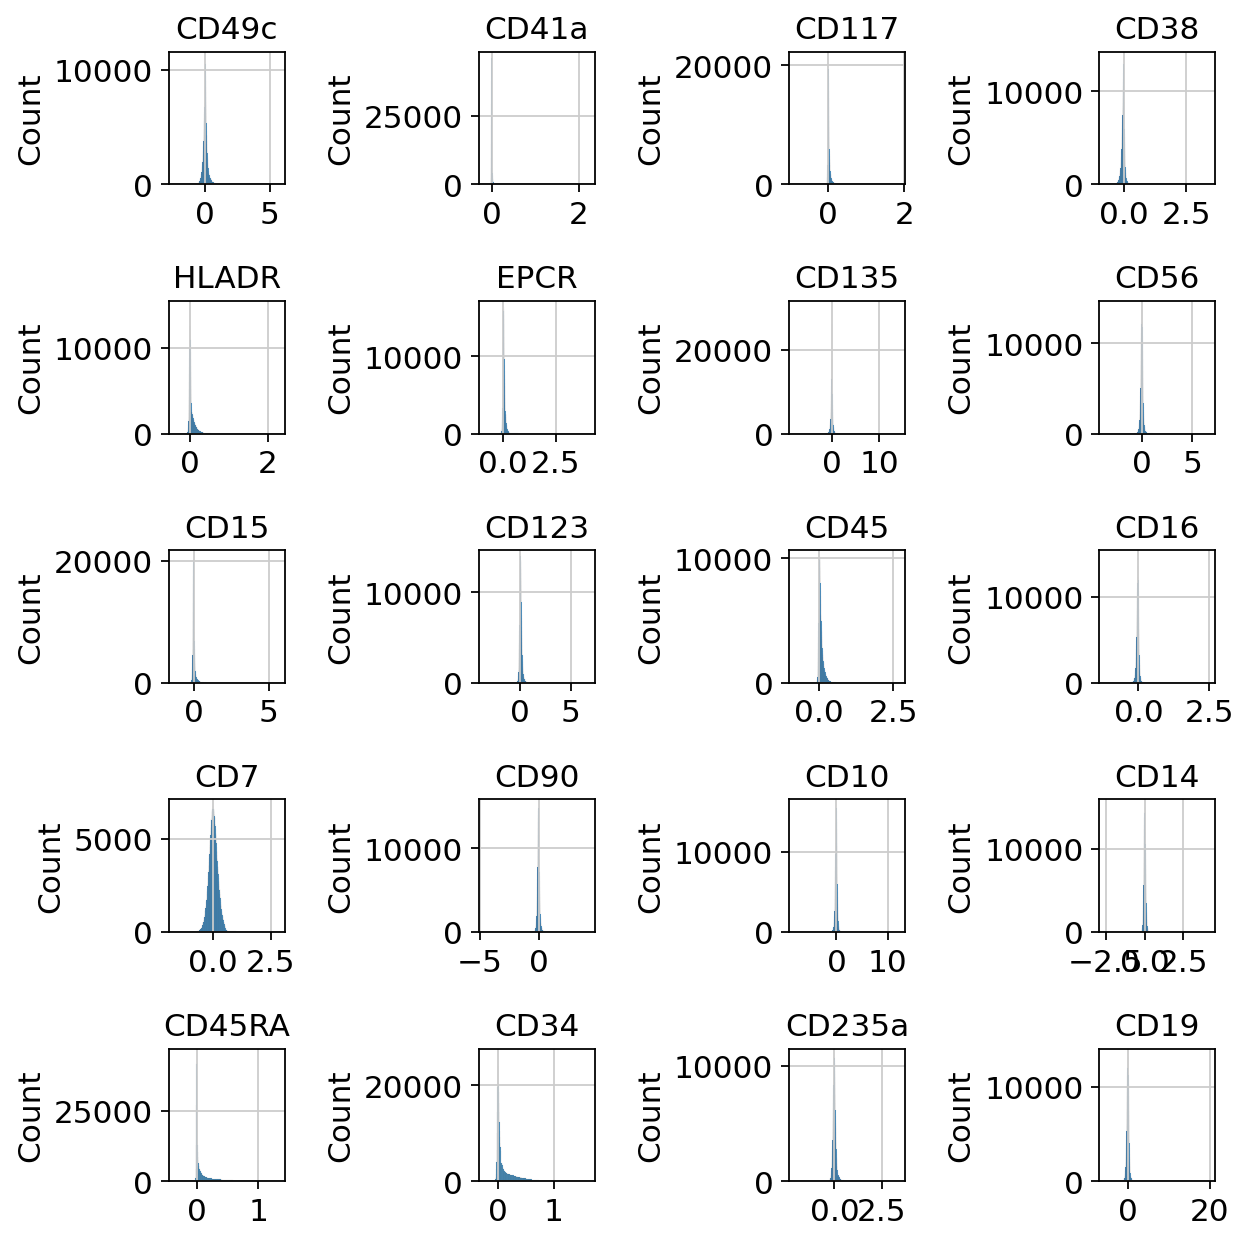

In [28]:
X = adata.X
if not isinstance(X, np.ndarray):
    X = X.toarray()

feature_names = adata.var_names

fig, axes = plt.subplots(5, 4, figsize=(8, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < X.shape[1]:  # ensure we don't go out of bounds
        sns.histplot(X[:, i], ax=ax, kde=False)
        ax.set_title(feature_names[i])
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1916720/2551590629.py:1: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(figsize=(4,3))


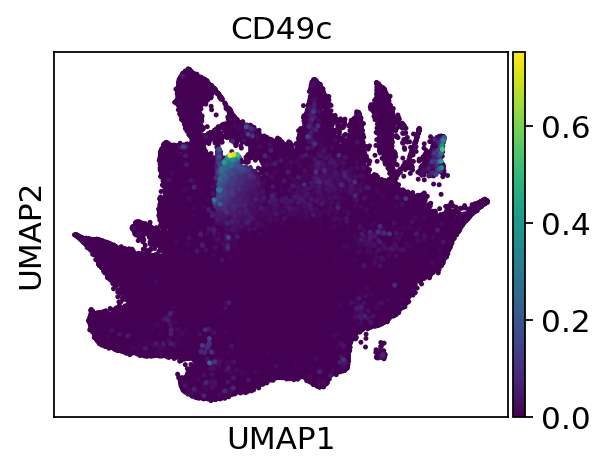

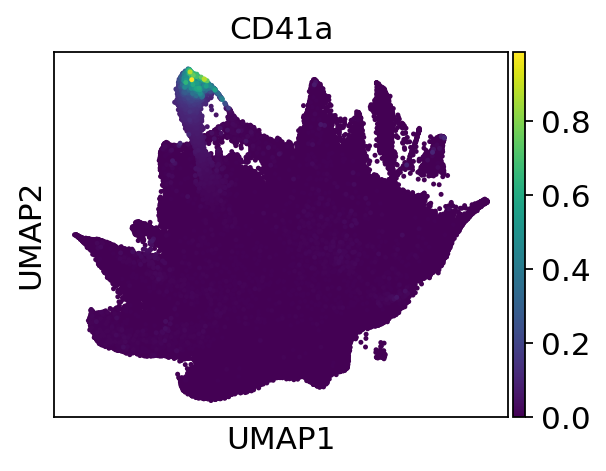

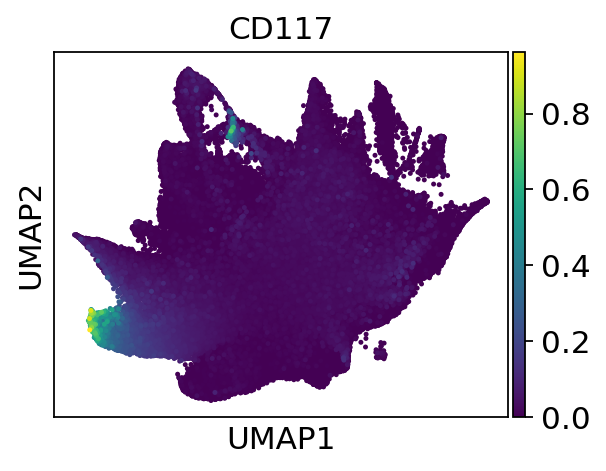

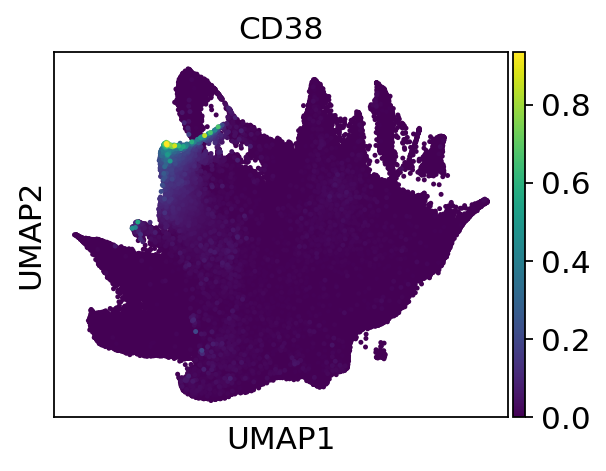

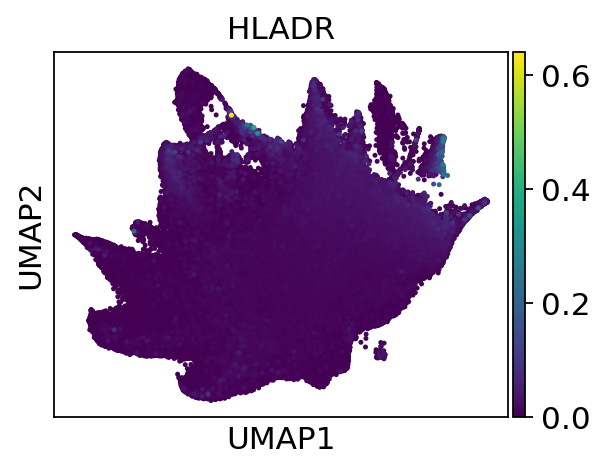

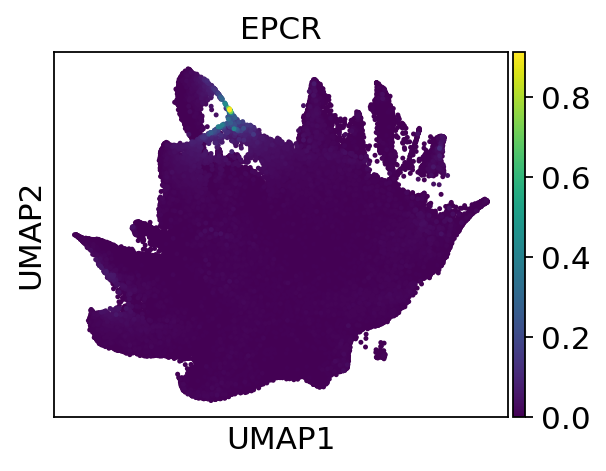

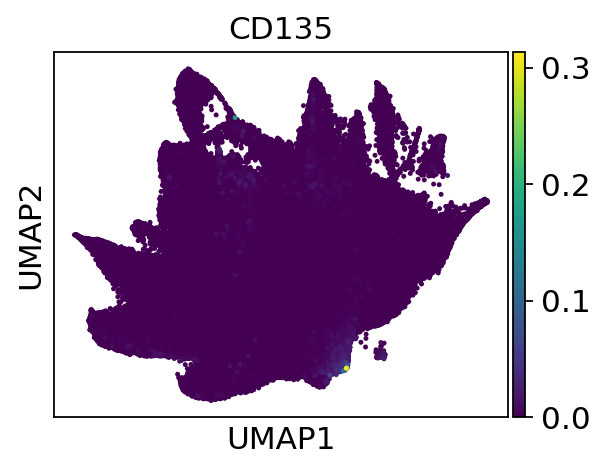

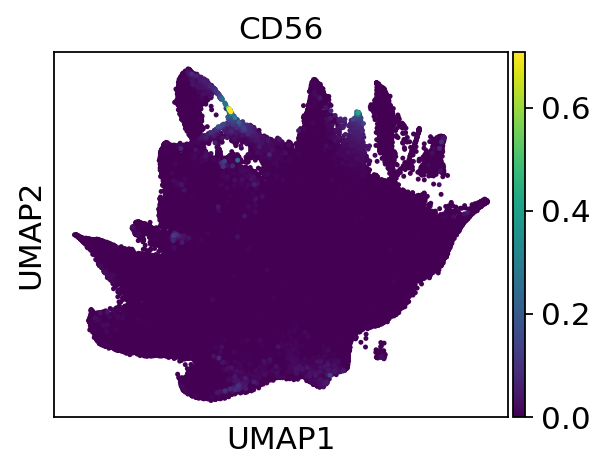

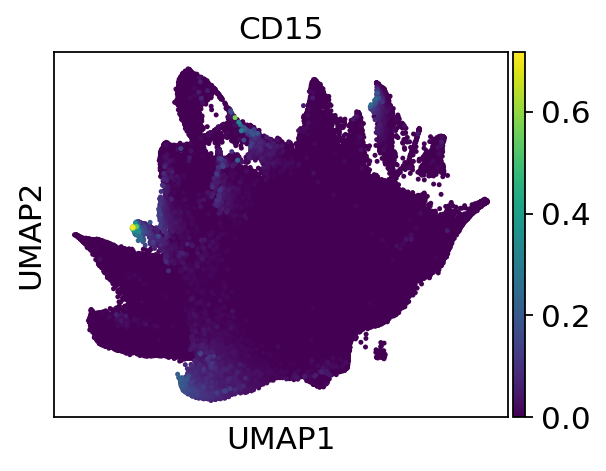

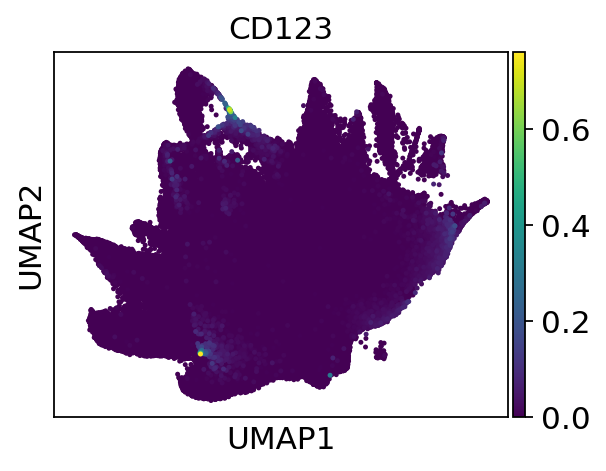

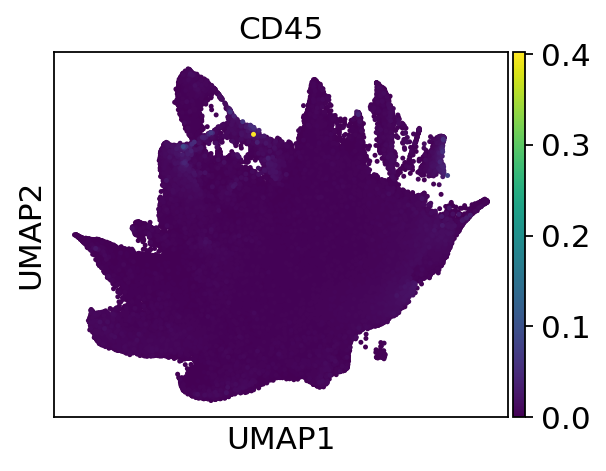

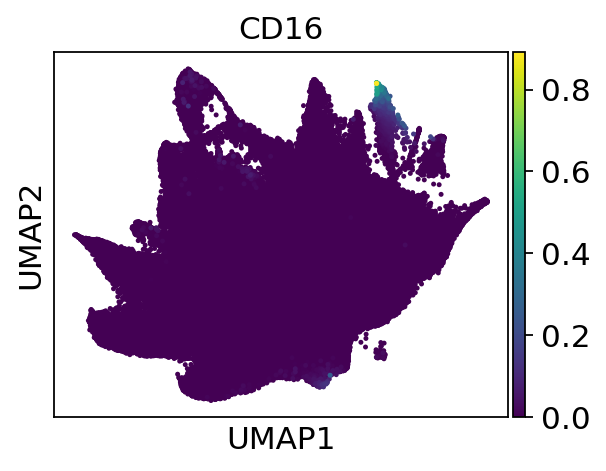

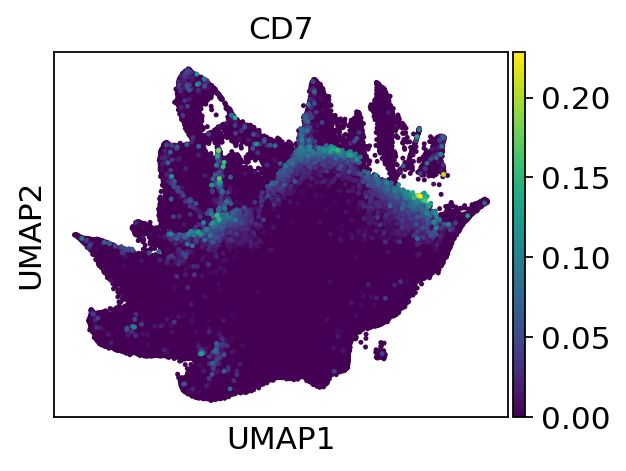

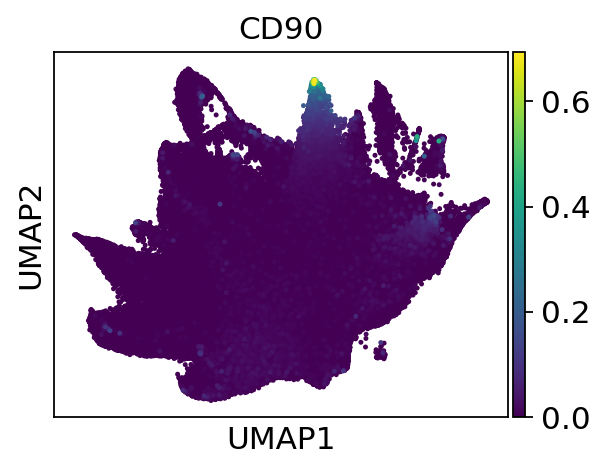

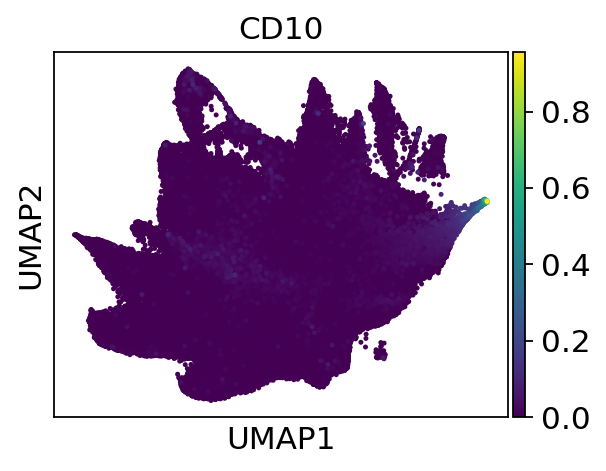

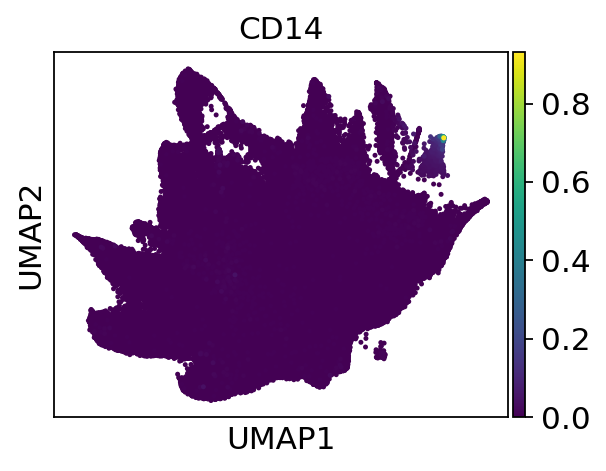

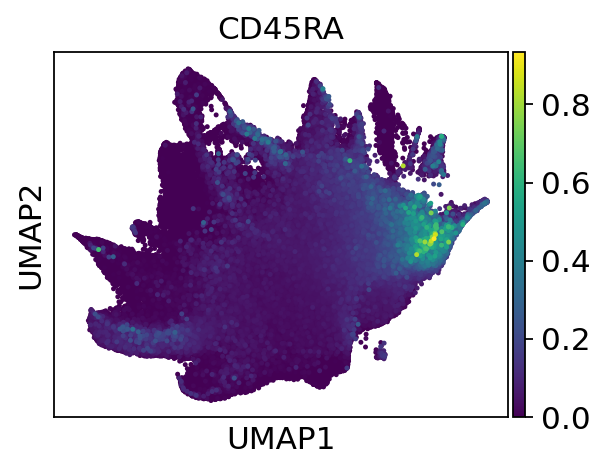

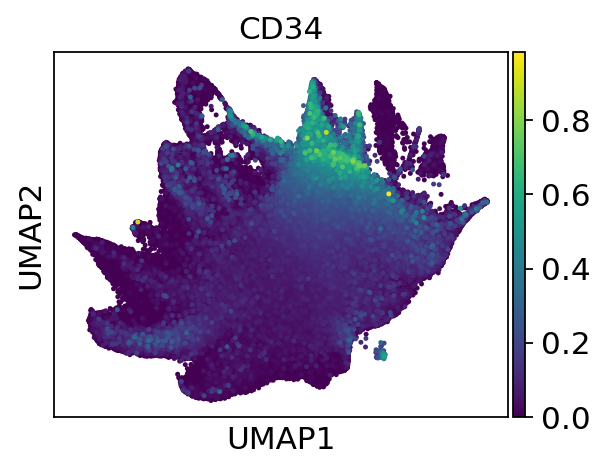

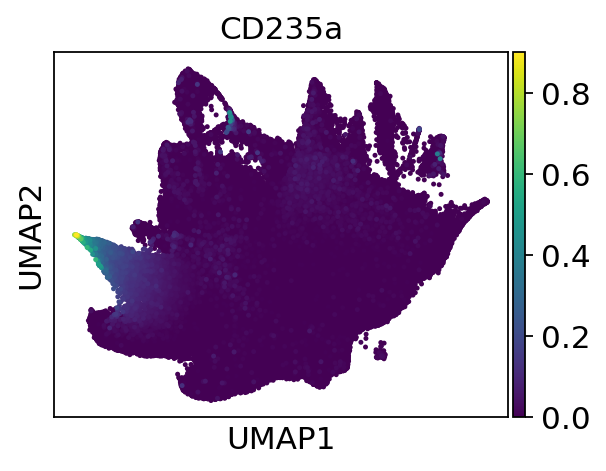

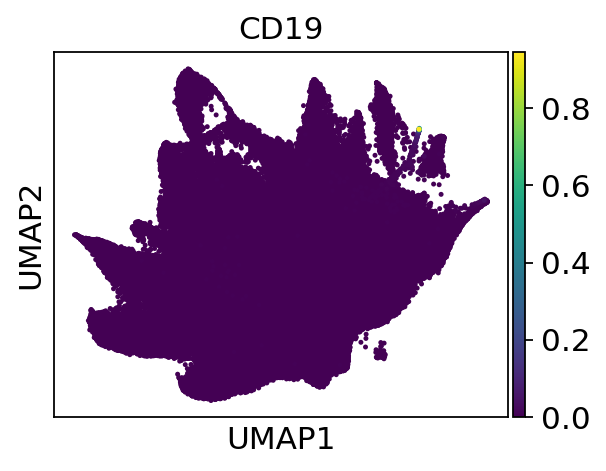

In [29]:
sc.settings.set_figure_params(figsize=(4,3))

for unique_marker in adata.var.index:
    sc.pl.umap(adata, color=unique_marker, s=20)

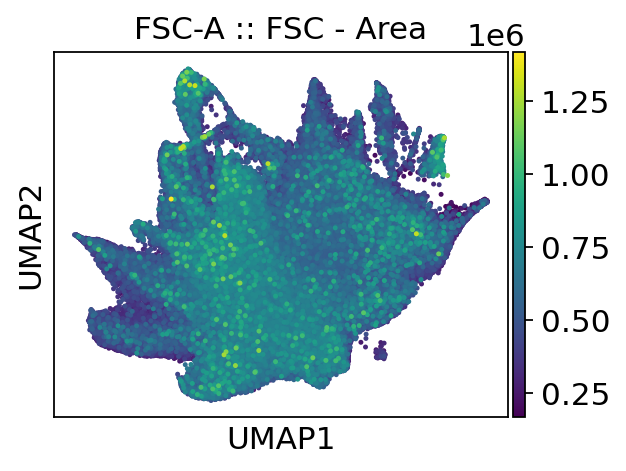

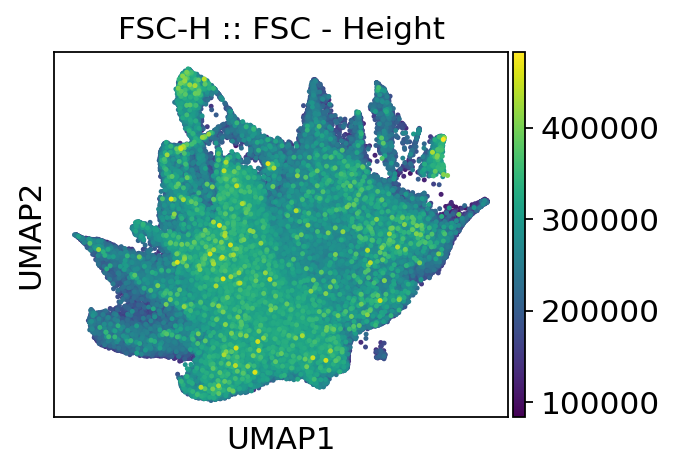

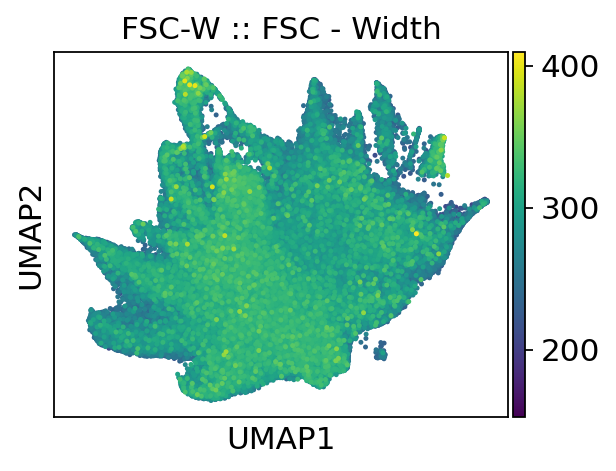

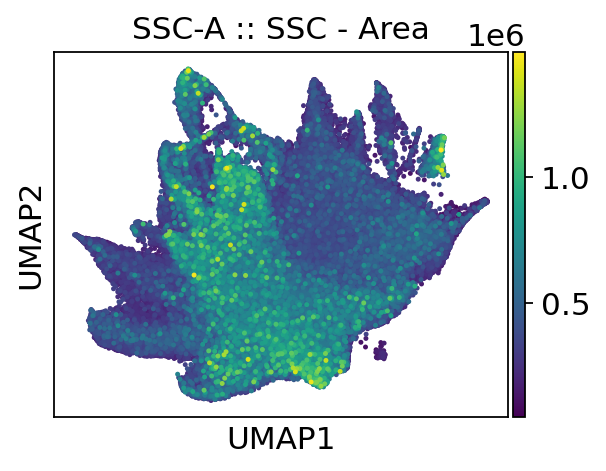

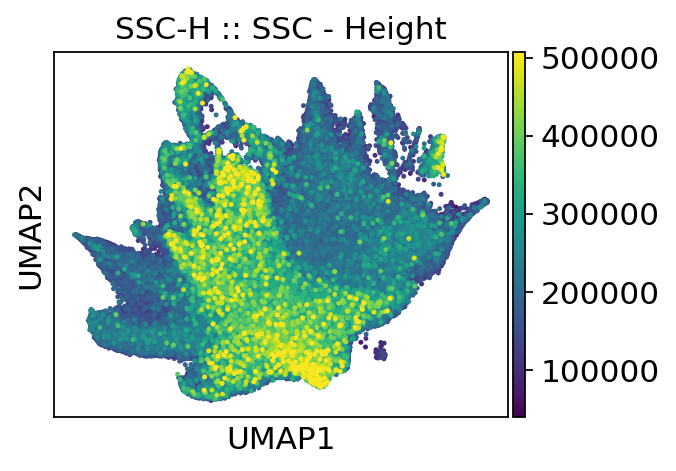

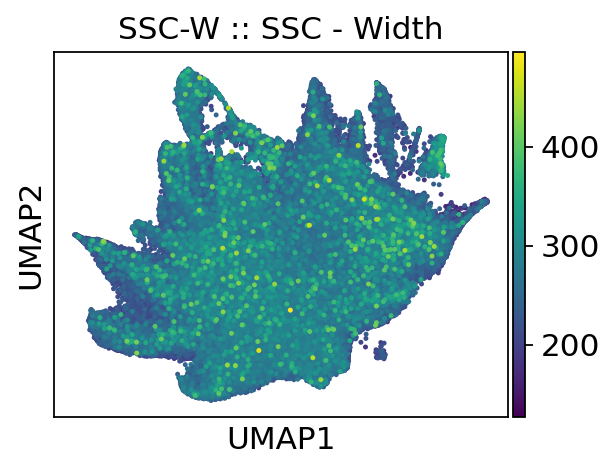

In [30]:
for col in ['FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width']:
    sc.pl.umap(adata, color=col, s=20)

## Equivalence buty and TPO


In [31]:
adata_exp = adata[adata.obs.experiment_number.isin([113, 119])]
df = adata_exp.obs.copy()

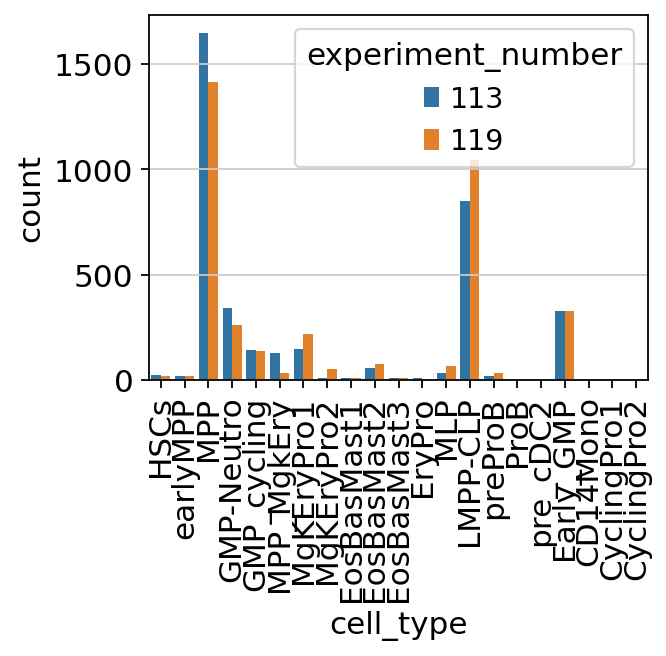

In [32]:
sns.countplot(
    data=df,
    x="cell_type",
    hue="experiment_number"
)
plt.xticks(rotation=90)
plt.show()

In [33]:
adata[adata.obs.experiment_number==210].obs.loc[:, ["tpo_[ng_ml]", "butyzamide_[nm]"]]

,tpo_[ng_ml],butyzamide_[nm]
124883-707,0.0,100
257601-707,0.0,100
302964-705,0.0,100
158408-705,0.0,100
234210-705,0.0,100
...,...,...
31587-707,0.0,100
38281-705,0.0,100
68487-705,0.0,100
74821-707,0.0,100


In [34]:
adata.obs.loc[:, ["tpo_[ng_ml]", "butyzamide_[nm]"]]

,tpo_[ng_ml],butyzamide_[nm]
223430-121,2.5,0
64004-120,2.5,0
78783-120,2.5,0
438603-122,2.5,0
218417-119,2.5,0
...,...,...
1104-273,0.0,100
633-273,0.0,100
8904-277,0.0,100
2148-277,0.0,100


In [35]:
adata.obs.columns

Index(['experiment_number', 'replicate', 'date', 'cytometer',
       'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts',
       'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]',
       'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]',
       'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]',
       'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]',
       'source_cell_phenotype', 'total_count_beads',
       'counts_source_cell_phenotype', 'days_of_culture', 'plate',
       'absolute_number_multiplier_[2^n]', 'cytometer_id',
       'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width',
       'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width',
       'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub',
       'leiden_old', 'cell_type'],
      dtype='object')

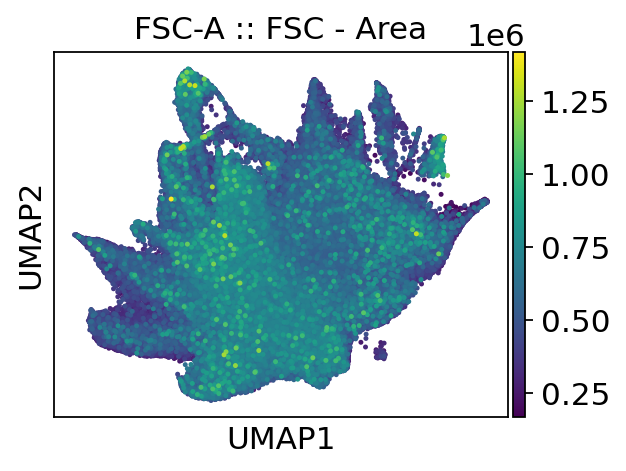

In [36]:
sc.pl.umap(adata, color="FSC-A :: FSC - Area", s=20)

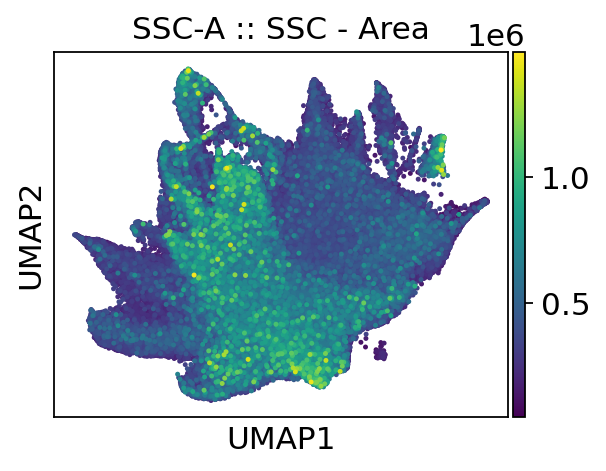

In [37]:
sc.pl.umap(adata, color="SSC-A :: SSC - Area", s=20)

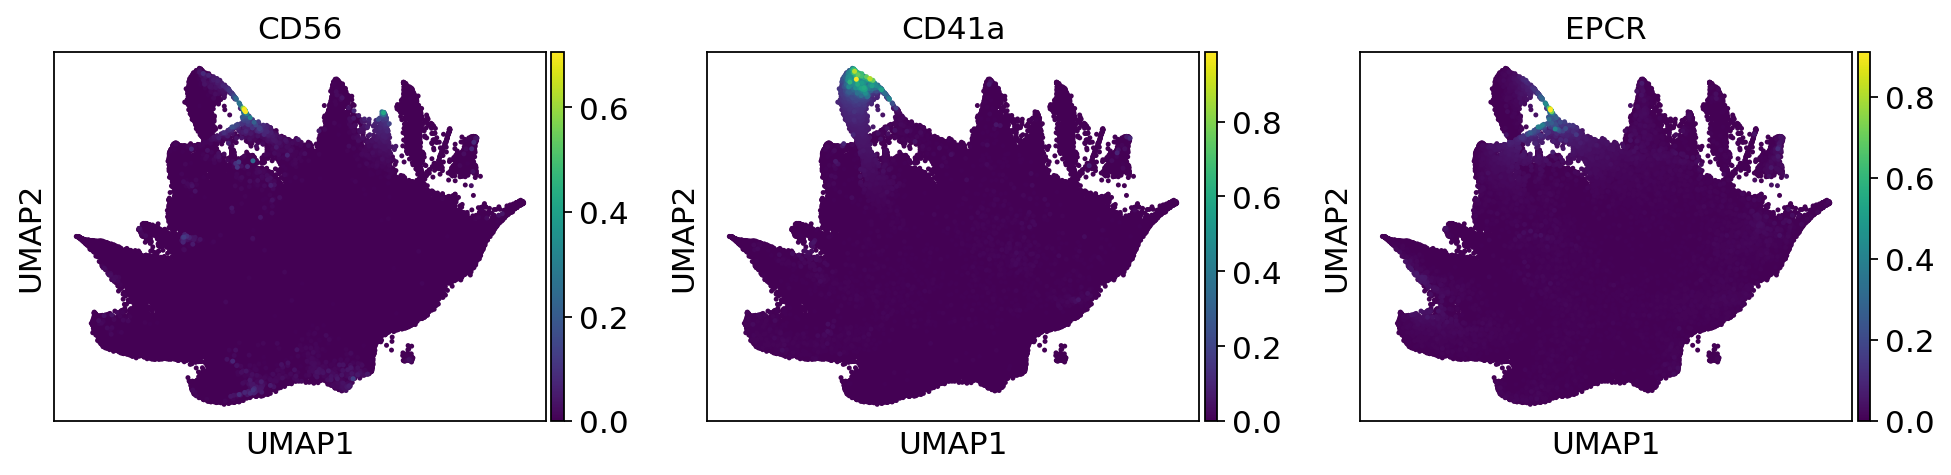

In [38]:
sc.pl.umap(adata, color=["CD56", "CD41a", "EPCR"], s=20)

In [39]:
adata_copy = adata.copy()
adata_copy.obs.experiment_number = adata_copy.obs.experiment_number.astype("category")

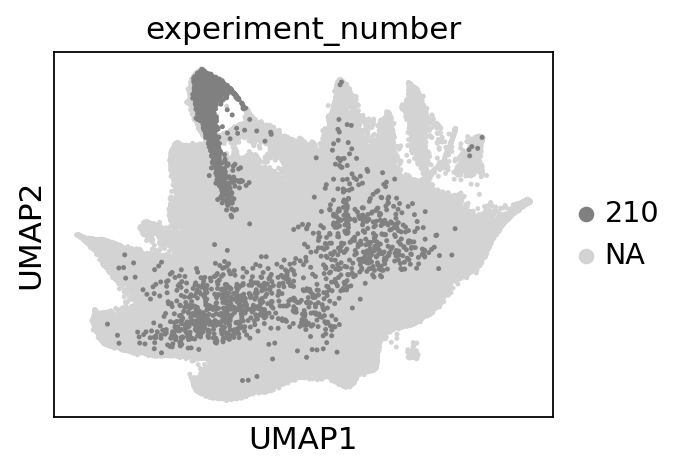

In [40]:
sc.pl.umap(adata_copy, color="experiment_number", groups=[210],  s=20)

(array([601., 550., 431., 438., 476., 464., 525., 586., 353.,  46.]),
 array([0.06089001, 0.28033927, 0.49978852, 0.71923774, 0.93868703,
        1.15813625, 1.37758541, 1.59703469, 1.81648397, 2.03593326,
        2.25538254]),
 <BarContainer object of 10 artists>)

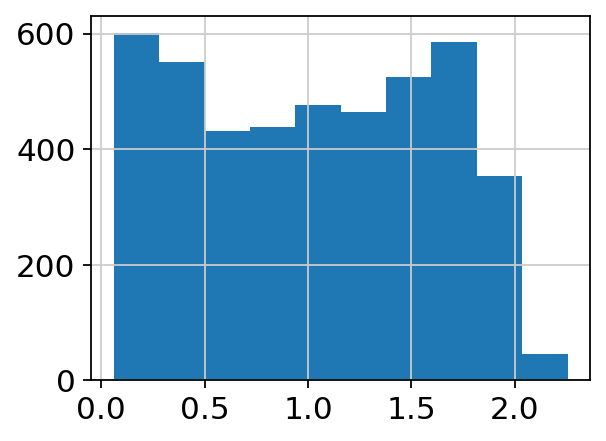

In [41]:
# adata_log_mgkPro = 
plt.hist(adata[adata.obs.cell_type=="late_MgkPro"][:, "CD41a"].X)

## Plot protocols and proportions 

In [83]:
protocol_adata.obs = protocol_adata.obs.drop(["cell_counts", "experiment_id"], axis=1)

KeyError: "['cell_counts', 'experiment_id'] not found in axis"

In [90]:
rename_map = {
    "late_MgkPro": "MgkPro",
    "pre_cDC1": "Pre-DC1",
    "pre_cDC2": "Pre-DC2",
    "GMP_cycling": "GMP-cycling",
    "Early_GMP": "Early-GMP",
    "MPP_MgkEry": "MPP-MgkEry"
}

protocol_adata.obs.columns = protocol_adata.obs.columns.map(lambda x: rename_map.get(x, x))

In [91]:
protocol_adata.obs.columns

Index(['LMPP-CLP', 'GMP-cycling', 'EosBasMast2', 'MgKEryPro1', 'GMP-Neutro',
       'EosBasMast3', 'Early-GMP', 'MPP', 'MgKEryPro2', 'EosBasMast1',
       'Pre-DC2', 'preProB', 'MPP-MgkEry', 'Pre-DC1', 'MLP', 'earlyMPP',
       'CyclingPro1', 'CyclingPro2', 'CD14Mono', 'HSCs', 'EryPro', 'MgkPro',
       'CD16Mono', 'ProB'],
      dtype='object')

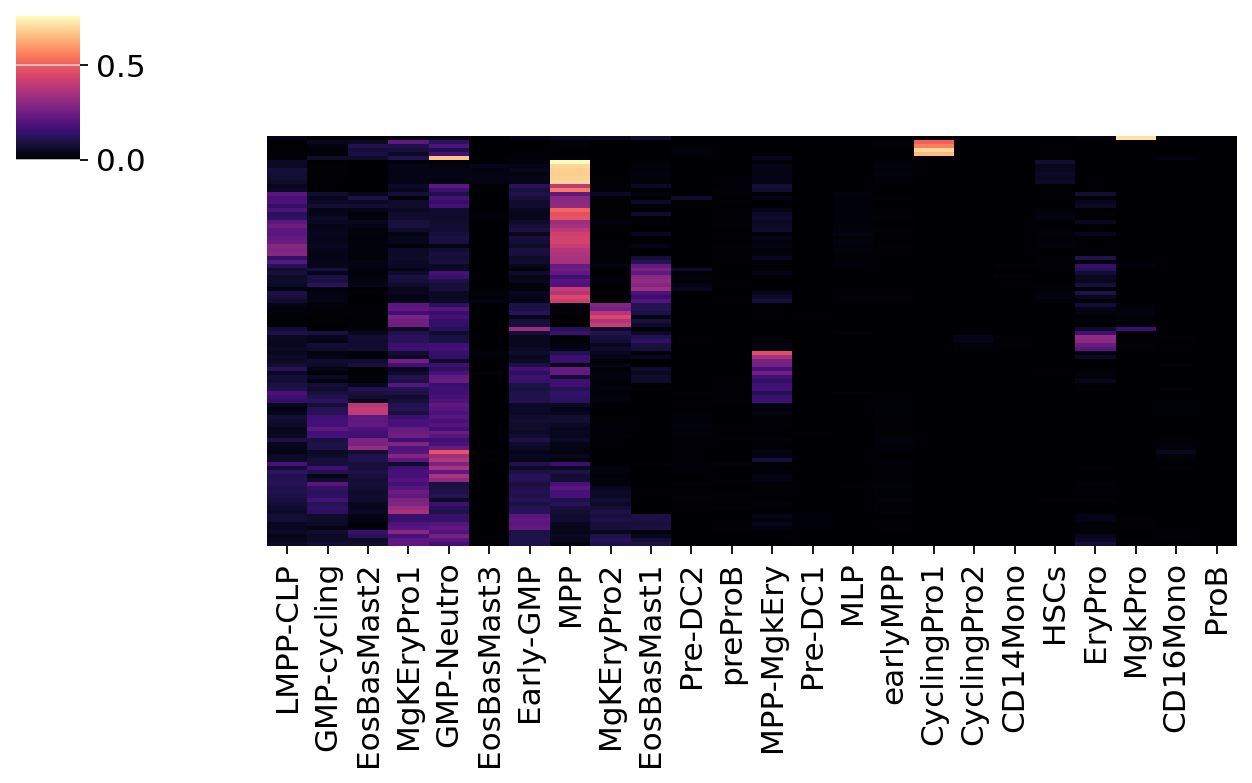

In [100]:
# g = sns.clustermap(protocol_adata.obs.values.T, figsize=(7, 7),
#                    yticklabels=protocol_adata.obs.columns,
#                    xticklabels=False, 
#                    col_cluster=True, 
#                    row_cluster=False
#                   )

g = sns.clustermap(protocol_adata.obs.values, figsize=(8, 5),
                   xticklabels=protocol_adata.obs.columns,
                   yticklabels=False,
                   row_cluster=True,
                   col_cluster=False,
                   cmap="magma")

g.ax_row_dendrogram.set_visible(False)
g.ax_heatmap.grid(False)

g.figure.savefig("clustermap.png", format="png", bbox_inches="tight", dpi=800)
plt.show()